In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import WeightedRandomSampler
from torch_geometric.nn.conv import GATConv, GCNConv, SplineConv
from torch_geometric.nn.norm import GraphNorm
from torch_geometric.nn import Sequential
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
import torch.utils.data as torchdata
import tqdm
from math import floor
import gc
import matplotlib.pyplot as plt
from Model.MENDR.MENDR import MENDR_model
from Model.MENDR.MENDREncoder import MENDRPatchEncoder
from Model.MENDR.mAtt.optimizer import MixOptimizer
from Model.MENDR.mAtt.spd import SPDTangentSpace
import random
import os
import math
from Datasets.datasetTUEV import WaveletTUEVDataset
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, precision_recall_curve, auc, f1_score, cohen_kappa_score
from torchjd import mtl_backward
from torchjd.aggregation import UPGrad

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [3]:
seed = 210
### Seed ###
torch.cuda.empty_cache()
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [4]:
print("*" * 50)
finetune_train_dataset = WaveletTUEVDataset(root="/home/hice1/mchen439/scratch/TUEV/train", frac=1.0, split="train")
print("Dataset Loaded. Length of Train Dataset: ", len(finetune_train_dataset))
finetune_test_dataset = WaveletTUEVDataset(root="/home/hice1/mchen439/scratch/TUEV/eval", frac=1.0, split="eval")
print("Dataset Loaded. Length of Test Dataset: ", len(finetune_test_dataset))

**************************************************
Loading 83932 folders


100%|██████████| 83932/83932 [04:33<00:00, 307.34it/s]


Dataset Loaded. Length of Train Dataset:  83932
Loading 29421 folders


100%|██████████| 29421/29421 [01:36<00:00, 303.89it/s]

Dataset Loaded. Length of Test Dataset:  29421


In [5]:
#finetune_train_dataset, finetune_val_dataset = torchdata.random_split(finetune_train_dataset, [0.8, 0.2])
#print(len(finetune_train_dataset), len(finetune_val_dataset))

In [6]:
print(finetune_train_dataset[0]['graph'])
print(finetune_train_dataset[0]['delta'].shape)
print(finetune_train_dataset[0]['theta'].shape)
print(finetune_train_dataset[0]['alpha'].shape)
print(finetune_train_dataset[0]['beta'].shape)
print(finetune_train_dataset[0]['gamma'].shape)
print(finetune_train_dataset[0]['graph'].y)
print(finetune_train_dataset[1]['graph'].y)
print(finetune_train_dataset[2]['graph'].y)
print(finetune_train_dataset[3]['graph'].y)
print(finetune_train_dataset[4]['graph'].y)
print(finetune_train_dataset[5]['graph'].y)
print(finetune_train_dataset[6]['graph'].y)
print(finetune_train_dataset[7]['graph'].y)
print(finetune_train_dataset[8]['graph'].y)
print(finetune_train_dataset[9]['graph'].y)
print(finetune_test_dataset[0]['graph'].y)
print(finetune_test_dataset[29000]['graph'].y)
print(finetune_test_dataset[29010]['graph'].y)
print(finetune_test_dataset[29020]['graph'].y)
print(finetune_test_dataset[29030]['graph'].y)

Data(edge_index=[2, 361], edge_attr=[361, 1], pos=[19, 3], y=[1])
torch.Size([19, 86])
torch.Size([19, 86])
torch.Size([19, 166])
torch.Size([19, 326])
torch.Size([19, 645])
tensor([2])
tensor([5])
tensor([5])
tensor([5])
tensor([5])
tensor([5])
tensor([1])
tensor([5])
tensor([4])
tensor([5])
tensor([5])
tensor([5])
tensor([5])
tensor([5])
tensor([5])


In [7]:
train_label_count = {
    0: 0,
    1: 0,
    2: 0,
    3: 0,
    4: 0,
    5: 0
}
y_train = []
for i in range(len(finetune_train_dataset)):
    graph = finetune_train_dataset[i]['graph']
    train_label = graph.y.item()
    assert train_label >= 0 and train_label <= 5, f"Label {train_label} is not in range [0, 5]"
    train_label_count[train_label] += 1
    y_train.append(train_label)

print(train_label_count)

{0: 645, 1: 11254, 2: 6184, 3: 1070, 4: 11053, 5: 53726}


In [8]:
test_label_count = {
    0: 0,
    1: 0,
    2: 0,
    3: 0,
    4: 0,
    5: 0
}

y_test = []
for i in range(len(finetune_test_dataset)):
    graph = finetune_test_dataset[i]['graph']
    test_label = graph.y.item()
    assert test_label >= 0 and test_label <= 5, f"{test_label} is not a valid label"
    test_label_count[test_label] += 1
    y_test.append(test_label)

print(test_label_count)

{0: 567, 1: 4677, 2: 1998, 3: 329, 4: 2204, 5: 19646}


In [9]:
train_label_counts_arr = np.array(list(train_label_count.values()))
train_sampler_class_weight = 1. / torch.from_numpy(train_label_counts_arr)
train_samples_weight = np.array([train_sampler_class_weight[t] for t in y_train])
train_sampler = WeightedRandomSampler(weights=train_samples_weight, num_samples=len(train_samples_weight))

test_label_counts_arr = np.array(list(test_label_count.values()))
test_sampler_class_weight = 1. / torch.from_numpy(test_label_counts_arr)
test_samples_weight = np.array([test_sampler_class_weight[t] for t in y_test])
test_sampler = WeightedRandomSampler(weights=test_samples_weight, num_samples=len(test_samples_weight))

print(train_sampler_class_weight)
print(test_sampler_class_weight)
print(train_samples_weight.shape)
print(test_samples_weight.shape)

tensor([1.5504e-03, 8.8857e-05, 1.6171e-04, 9.3458e-04, 9.0473e-05, 1.8613e-05])
tensor([1.7637e-03, 2.1381e-04, 5.0050e-04, 3.0395e-03, 4.5372e-04, 5.0901e-05])
(83932,)
(29421,)


In [10]:
finetune_train_loader = DataLoader(finetune_train_dataset, batch_size=64, num_workers=16, pin_memory=True, persistent_workers=True, shuffle=True)
#finetune_val_loader = DataLoader(finetune_val_dataset, batch_size=64, num_workers=16, pin_memory=True, persistent_workers=True, shuffle=False)
finetune_test_loader = DataLoader(finetune_test_dataset, batch_size=64, num_workers=16, pin_memory=True, persistent_workers=True, shuffle=False)
print(len(finetune_train_loader), len(finetune_test_loader))
#print(len(finetune_train_loader), len(finetune_val_loader), len(finetune_test_loader))
BANDS = ['delta', 'theta', 'alpha', 'beta', 'gamma']

1312 460


In [11]:
class FinetuneDomainAdapter(nn.Module):
    def __init__(self, device):
        super().__init__()
        self.device = device

        self.adaptors = nn.ParameterDict({
            'delta': nn.Sequential(nn.Conv1d(19, 19, kernel_size=1, stride=1, padding=0), nn.LayerNorm((19, 86))),
            'theta': nn.Sequential(nn.Conv1d(19, 19, kernel_size=1, stride=1, padding=0), nn.LayerNorm((19, 86))),
            'alpha': nn.Sequential(nn.Conv1d(19, 19, kernel_size=1, stride=1, padding=0), nn.LayerNorm((19, 166))),
            'beta':  nn.Sequential(nn.Conv1d(19, 19, kernel_size=1, stride=1, padding=0), nn.LayerNorm((19, 326))),
            'gamma': nn.Sequential(nn.Conv1d(19, 19, kernel_size=1, stride=1, padding=0), nn.LayerNorm((19, 645))),
        })
         
    def forward(self, x):
        x_out = dict()
        for band, adaptor in self.adaptors.items():
            x_out[band] = adaptor(x[band])
        return x_out

class FinetuneDecoder(nn.Module):
    def __init__(self, device):
        super().__init__()
        self.tangent = SPDTangentSpace(19, device=device)
        self.flatten = nn.Flatten()

        self.band_encoding_decoding_dim = {
            'delta': 19*25,
            'theta': 19*25,
            'alpha': 38*25,
            'beta':  76*25,
            'gamma': 114*25,
        }

        self.band_encoding_decoders = nn.ParameterDict({
            'delta': nn.Sequential(nn.LayerNorm(self.band_encoding_decoding_dim['delta']), nn.GELU(), nn.Linear(self.band_encoding_decoding_dim['delta'], 10), nn.LayerNorm(10), nn.GELU()),
            'theta': nn.Sequential(nn.LayerNorm(self.band_encoding_decoding_dim['theta']), nn.GELU(), nn.Linear(self.band_encoding_decoding_dim['theta'], 10), nn.LayerNorm(10), nn.GELU()),
            'alpha': nn.Sequential(nn.LayerNorm(self.band_encoding_decoding_dim['alpha']), nn.GELU(), nn.Linear(self.band_encoding_decoding_dim['alpha'], 10), nn.LayerNorm(10), nn.GELU()),
            'beta':  nn.Sequential(nn.LayerNorm(self.band_encoding_decoding_dim['beta']), nn.GELU(), nn.Linear(self.band_encoding_decoding_dim['beta'], 10), nn.LayerNorm(10), nn.GELU()),
            'gamma': nn.Sequential(nn.LayerNorm(self.band_encoding_decoding_dim['gamma']), nn.GELU(), nn.Linear(self.band_encoding_decoding_dim['gamma'], 10), nn.LayerNorm(10), nn.GELU()),
        })

        self.band_tangent_spaces = nn.ParameterDict({
            'delta': SPDTangentSpace(19, device=device),
            'theta': SPDTangentSpace(19, device=device),
            'alpha': SPDTangentSpace(19, device=device),
            'beta':  SPDTangentSpace(19, device=device),
            'gamma': SPDTangentSpace(19, device=device),
        })

        self.band_flatten = nn.ParameterDict({
            'delta': nn.Flatten(),
            'theta': nn.Flatten(),
            'alpha': nn.Flatten(),
            'beta':  nn.Flatten(),
            'gamma': nn.Flatten(),
        })

        self.band_dim = {
            'delta': 19,
            'theta': 19,
            'alpha': 19,
            'beta':  19,
            'gamma': 19,
        }

        self.flattened = (19 * 20) // 2

        self.band_decoders = nn.ParameterDict({
            'delta': nn.Sequential(nn.LayerNorm(self.flattened), nn.GELU(), nn.Linear(self.flattened, 10), nn.LayerNorm(10), nn.GELU()),
            'theta': nn.Sequential(nn.LayerNorm(self.flattened), nn.GELU(), nn.Linear(self.flattened, 10), nn.LayerNorm(10), nn.GELU()),
            'alpha': nn.Sequential(nn.LayerNorm(self.flattened), nn.GELU(), nn.Linear(self.flattened, 10), nn.LayerNorm(10), nn.GELU()),
            'beta':  nn.Sequential(nn.LayerNorm(self.flattened), nn.GELU(), nn.Linear(self.flattened, 10), nn.LayerNorm(10), nn.GELU()),
            'gamma': nn.Sequential(nn.LayerNorm(self.flattened), nn.GELU(), nn.Linear(self.flattened, 10), nn.LayerNorm(10), nn.GELU()),
        })
        self.combined_seq = nn.Sequential(nn.LayerNorm(19 * 10), nn.GELU(), nn.Linear(19*10, 10), nn.LayerNorm(10), nn.GELU())
        self.final_decoder = nn.Sequential(nn.Linear(5*10 + 10 + 5*10, 80), nn.LayerNorm(80), nn.GELU(), nn.Dropout(p=0.2), nn.Linear(80, 20), nn.LayerNorm(20), nn.GELU(), nn.Dropout(p=0.2))
        self.final_lin = nn.Linear(20, 6)

    def forward(self, encodings, wavelet_manifold_output, combined_manifold_output):
        batch_size = combined_manifold_output.shape[0]
        num_patches = combined_manifold_output.shape[1]
        embedding_dim = combined_manifold_output.shape[2]

        band_encodings_decodings = []
        for band, band_encodings in encodings.items():
            band_encodings = band_encodings.reshape(band_encodings.shape[0], self.band_encoding_decoding_dim[band])
            band_encoding_decoding = self.band_encoding_decoders[band](band_encodings)
            band_encodings_decodings.append(band_encoding_decoding)
        band_encodings_decodings = torch.cat(band_encodings_decodings, dim=1)

        band_decodings = []
        for band, encodings in wavelet_manifold_output.items():
            band_tangent = self.band_tangent_spaces[band](encodings.view(batch_size*num_patches, self.band_dim[band], self.band_dim[band]))
            band_tangent = self.band_flatten[band](band_tangent)
            band_decoding = self.band_decoders[band](band_tangent)
            band_decodings.append(band_decoding)
        band_decodings = torch.cat(band_decodings, dim=1)

        x = self.tangent(combined_manifold_output.view(batch_size*num_patches, embedding_dim, embedding_dim))
        x = self.flatten(x)
        x = self.combined_seq(x)
        x = self.final_decoder(torch.cat([x, band_decodings, band_encodings_decodings], dim=1))
        x = self.final_lin(x)
        return x

class FinetuneDecoderTiny(nn.Module):
    def __init__(self, device):
        super().__init__()
        self.tangent = SPDTangentSpace(19, device=device)
        self.flatten = nn.Flatten()

        self.band_encoding_decoding_dim = {
            'delta': 19*25,
            'theta': 19*25,
            'alpha': 38*25,
            'beta':  76*25,
            'gamma': 114*25,
        }

        self.band_encoding_decoders = nn.ParameterDict({
            'delta': nn.Sequential(nn.LayerNorm(self.band_encoding_decoding_dim['delta']), nn.GELU(), nn.Linear(self.band_encoding_decoding_dim['delta'], 10), nn.LayerNorm(10), nn.GELU()),
            'theta': nn.Sequential(nn.LayerNorm(self.band_encoding_decoding_dim['theta']), nn.GELU(), nn.Linear(self.band_encoding_decoding_dim['theta'], 10), nn.LayerNorm(10), nn.GELU()),
            'alpha': nn.Sequential(nn.LayerNorm(self.band_encoding_decoding_dim['alpha']), nn.GELU(), nn.Linear(self.band_encoding_decoding_dim['alpha'], 10), nn.LayerNorm(10), nn.GELU()),
            'beta':  nn.Sequential(nn.LayerNorm(self.band_encoding_decoding_dim['beta']), nn.GELU(), nn.Linear(self.band_encoding_decoding_dim['beta'], 10), nn.LayerNorm(10), nn.GELU()),
            'gamma': nn.Sequential(nn.LayerNorm(self.band_encoding_decoding_dim['gamma']), nn.GELU(), nn.Linear(self.band_encoding_decoding_dim['gamma'], 10), nn.LayerNorm(10), nn.GELU()),
        })

    
        self.band_dim = {
            'delta': 19,
            'theta': 19,
            'alpha': 19,
            'beta':  19,
            'gamma': 19,
        }

        self.flattened = (19 * 20) // 2

        self.combined_seq = nn.Sequential(nn.LayerNorm(19 * 10), nn.GELU(), nn.Linear(19*10, 10), nn.LayerNorm(10), nn.GELU())
        self.final_decoder = nn.Sequential(nn.Linear(10 + 5*10, 40), nn.LayerNorm(40), nn.GELU(), nn.Dropout(p=0.2), nn.Linear(40, 20), nn.LayerNorm(20), nn.GELU(), nn.Dropout(p=0.2))
        self.final_lin = nn.Linear(20, 6)

    def forward(self, encodings, combined_manifold_output):
        batch_size = combined_manifold_output.shape[0]
        num_patches = combined_manifold_output.shape[1]
        embedding_dim = combined_manifold_output.shape[2]

        band_encodings_decodings = []
        for band, band_encodings in encodings.items():
            band_encodings = band_encodings.reshape(band_encodings.shape[0], self.band_encoding_decoding_dim[band])
            band_encoding_decoding = self.band_encoding_decoders[band](band_encodings)
            band_encodings_decodings.append(band_encoding_decoding)
        band_encodings_decodings = torch.cat(band_encodings_decodings, dim=1)

        x = self.tangent(combined_manifold_output.view(batch_size*num_patches, embedding_dim, embedding_dim))
        x = self.flatten(x)
        x = self.combined_seq(x)
        x = self.final_decoder(torch.cat([x, band_encodings_decodings], dim=1))
        x = self.final_lin(x)
        return x

In [12]:
model = MENDR_model(device=device, contextualizer_size="TINY").to(device)
#model.load_state_dict(torch.load("./checkpoint/4b5781b2c41e45a7a666bb8c29b4ae22_14_LARGE/mendr_model_weights.pth", weights_only=True))
model_adaptor = FinetuneDomainAdapter(device).to(device)
model_decoder = FinetuneDecoderTiny(device).to(device)
'''
for p in model.parameters():
    p.requires_grad = False
'''
optim_params = []
optim_params.append({'params': model.mendr_encoder.parameters(), 'lr': 5e-4})
optim_params.append({'params': model.mendr_contextualizer.parameters(), 'lr': 5e-4})
optim_params.append({'params': model_adaptor.parameters(), 'lr': 5e-4})
optim_params.append({'params': model_decoder.parameters(), 'lr': 5e-4})
optimizer = MixOptimizer(torch.optim.AdamW(optim_params, lr=5e-4, weight_decay=0.5))
optimizer.set_scheduler_t0(len(finetune_train_loader) * 10)
for p in model.mendr_contextualizer.parameters():
    p.register_hook(lambda grad: torch.clamp(grad, -1e7, 1e7))
for p in model_adaptor.parameters():
    p.register_hook(lambda grad: torch.clamp(grad, -1e7, 1e7))
for p in model_decoder.parameters():
    p.register_hook(lambda grad: torch.clamp(grad, -1e7, 1e7))
aggregator = UPGrad(pref_vector=torch.tensor([1, 1, 1, 1, 1, 1]).to(device))
print("Total MENDR parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))
print("Total model_adaptor parameters:", sum(p.numel() for p in model_adaptor.parameters() if p.requires_grad))
print("Total model_decoder parameters:", sum(p.numel() for p in model_decoder.parameters() if p.requires_grad))
total_encoder_params = 0
total_decoder_params = 0
for band in BANDS:
    print(f'{band} Encoder Params: {model.mendr_encoder.encoder_decoders[band].getEncoderParamCount()}')
    print(f'{band} Decoder Params: {model.mendr_encoder.encoder_decoders[band].getDecoderParamCount()}')
    total_encoder_params += model.mendr_encoder.encoder_decoders[band].getEncoderParamCount()
    total_decoder_params += model.mendr_encoder.encoder_decoders[band].getDecoderParamCount()
#print(f'Wavelet Contextualizer Params: {sum(p.numel() for p in model.mendr_contextualizer.WaveletContextualizer.parameters() if p.requires_grad)}')
#print(f'Combined Contextualizer Params: {sum(p.numel() for p in model.mendr_contextualizer.CombinedContextualizer.parameters() if p.requires_grad)}')
print(f'Contextualizer Params: {sum(p.numel() for p in model.mendr_contextualizer.parameters() if p.requires_grad)}')
print("Total Encoder Params: ", total_encoder_params)
print("Total Decoder Params: ", total_decoder_params)

Set Cosine Annealing with Warm Restarts optimizer T_0 to: 13120
Total MENDR parameters: 2486098
Total model_adaptor parameters: 51642
Total model_decoder parameters: 85766
delta Encoder Params: 12597
delta Decoder Params: 22309
theta Encoder Params: 12597
theta Decoder Params: 22309
alpha Encoder Params: 14041
alpha Decoder Params: 101219
beta Encoder Params: 16929
beta Decoder Params: 498051
gamma Encoder Params: 22705
gamma Decoder Params: 1622675
Contextualizer Params: 108632
Total Encoder Params:  78869
Total Decoder Params:  2266563


In [13]:
def _fft_loss(output, target, loss_fn):
    hanning_window = torch.hann_window(output.shape[-1]).to(device)
    output_windowed = output * hanning_window.expand_as(output)
    target_windowed = target * hanning_window.expand_as(target)

    output_fft = torch.fft.fft(output_windowed, dim=-1)
    output_amplitude = torch.abs(output_fft)
    output_angle = torch.angle(output_fft)

    target_fft = torch.fft.fft(target_windowed, dim=-1)
    target_amplitude = torch.abs(target_fft)
    target_angle = torch.abs(target_fft)

    return (loss_fn(output_amplitude, target_amplitude) + (loss_fn(output_angle, target_angle)))

def calculate_band_loss(inputs, outputs, loss_fn, loss_type='real'):
    outputs_reshaped = outputs.reshape(inputs.shape[0], inputs.shape[1], inputs.shape[2], inputs.shape[3])
    if loss_type == 'real':
        loss = loss_fn(inputs, outputs_reshaped)
    elif loss_type == 'fourier':
        loss = _fft_loss(output_reshaped, inputs, loss_fn)
    else:
        loss = loss_fn(inputs, outputs_reshaped) + _fft_loss(output_reshaped, inputs, loss_fn) * 1e-2
    return loss

In [14]:
def train_one_epoch(model, epoch, adaptor, decoder, optimizer, task_loss_fn, recon_loss_fn, train_loader):
	task_loss_sum = 0
	recon_loss_sum = 0
	model.eval()
	decoder.train()

	pbar = tqdm.trange(len(train_loader), desc="Training")
	data_iterator = iter(train_loader)
	balanced_accuracies = []

	truths = []
	preds = []
	for iteration in pbar:
		data = next(data_iterator)
		relevant_bands = [data['delta'].float().to(device),
							data['theta'].float().to(device),
							data['alpha'].float().to(device),
							data['beta'].float().to(device),
							data['gamma'].float().to(device)]
		inputs = dict(zip(BANDS, relevant_bands))
		inputs = adaptor(inputs)
		patchified_inputs, encodings, decodings, wavelet_manifold_output, combined_manifold_output = model(data['graph'], inputs)
		encodings_relevant_patch = dict()
		for band, encoding in encodings.items():
			encodings_relevant_patch[band] = encoding[:, 1, :, 10:35][:, None, :, :]
	
		'''
		wavelet_manifold_output_relevant_patch = dict()
		for band, wavelet_manifold in wavelet_manifold_output.items():
			wavelet_manifold_output_relevant_patch[band] = wavelet_manifold[:, 1, :, :][:, None, :, :]
		prediction = decoder(encodings_relvant_patch, wavelet_manifold_output_relevant_patch, combined_manifold_output[:, 1, :, :][:, None, :, :]).float()
		'''
		prediction = decoder(encodings_relevant_patch, combined_manifold_output[:, 1, :, :][:, None, :, :]).float()

		ground_truth = data['graph'].y.to(device).long()
		task_loss = task_loss_fn(prediction, ground_truth)
		delta_loss = calculate_band_loss(patchified_inputs['delta'], decodings['delta'], recon_loss_fn)
		theta_loss = calculate_band_loss(patchified_inputs['theta'], decodings['theta'], recon_loss_fn)
		alpha_loss = calculate_band_loss(patchified_inputs['alpha'], decodings['alpha'], recon_loss_fn)
		beta_loss = calculate_band_loss(patchified_inputs['beta'],   decodings['beta'], recon_loss_fn)
		gamma_loss = calculate_band_loss(patchified_inputs['gamma'], decodings['gamma'], recon_loss_fn)
		# Borrowed from CBramod: https://github.com/wjq-learning/CBraMod/blob/e0002aaa87e77a954ce3a11cb1de1ea13e3585e2/finetune_evaluator.py
		with torch.no_grad():
			pred_y = torch.max(prediction, dim=-1)[1]
			truths += ground_truth.clone().cpu().squeeze().numpy().tolist()
			preds += pred_y.clone().cpu().squeeze().numpy().tolist()
			curr_balanced_accuracy = balanced_accuracy_score(ground_truth.clone().cpu().squeeze().numpy(), pred_y.clone().cpu().squeeze().numpy())
			curr_f1 = f1_score(ground_truth.clone().cpu().squeeze().numpy(), pred_y.clone().cpu().squeeze().numpy(), average='weighted')
			curr_cohen_kappa = cohen_kappa_score(ground_truth.clone().cpu().squeeze().numpy(), pred_y.clone().cpu().squeeze().numpy())
			balanced_accuracies.append(curr_balanced_accuracy)


		shared_features = [encoding for band, encoding in encodings.items()]
		task_params = [decoder.parameters()]
		for band in BANDS:
			model_params = model.mendr_encoder.encoder_decoders[band].getDecoderParams()
			task_params.append(model_params)
		optimizer.zero_grad()
		#task_loss.backward()
		mtl_backward(losses=[task_loss, delta_loss, theta_loss, alpha_loss, beta_loss, gamma_loss], features=shared_features, tasks_params=task_params, aggregator=aggregator)
		optimizer.step()
		optimizer.scheduler_step(epoch * len(train_loader) + iteration)
		task_loss_sum += task_loss.item()
		recon_loss = delta_loss.item() + theta_loss.item() + alpha_loss.item() + beta_loss.item() + gamma_loss.item()
		recon_loss_sum += recon_loss
		pbar.set_postfix(task_loss=task_loss.item(), recon_loss=recon_loss, balanced_accuracy=f'{curr_balanced_accuracy*100:.3f}', F1=f'{curr_f1*100:.3f}', Cohens_Kappa=f'{curr_cohen_kappa*100:.3f}', lr=optimizer.scheduler.get_last_lr()[0])

	truths = np.array(truths)
	preds = np.array(preds)

	average_balanced_accuracy = np.mean(balanced_accuracies)
	balanced_accuracy = balanced_accuracy_score(truths, preds)
	f1 = f1_score(truths, preds, average='weighted')
	cohens_kappa = cohen_kappa_score(truths, preds)
	print(f'Mean Acc: {balanced_accuracy} F1 Score: {f1} Average Balanced Accuracy: {average_balanced_accuracy} Cohen Kappa: {cohens_kappa}')
	return task_loss_sum, recon_loss_sum

In [15]:
def test_one_epoch(model, adaptor, decoder, task_loss_fn, recon_loss_fn, test_loader, mode='Validating'):
	task_loss_sum = 0
	recon_loss_sum = 0
	model.eval()
	decoder.eval()

	pbar = tqdm.trange(len(test_loader), desc=mode)
	data_iterator = iter(test_loader)
	balanced_accuracies = []

	truths = []
	preds = []
	with torch.no_grad():
		for iteration in pbar:
			data = next(data_iterator)
			relevant_bands = [data['delta'].float().to(device),
								data['theta'].float().to(device),
								data['alpha'].float().to(device),
								data['beta'].float().to(device),
								data['gamma'].float().to(device)]
			inputs = dict(zip(BANDS, relevant_bands))
			inputs = adaptor(inputs)
			patchified_inputs, encodings, decodings, wavelet_manifold_output, combined_manifold_output = model(data['graph'], inputs)
			encodings_relevant_patch = dict()
			for band, encoding in encodings.items():
				encodings_relevant_patch[band] = encoding[:, 1, :, 10:35][:, None, :, :]
			'''
			wavelet_manifold_output_relevant_patch = dict()
			for band, wavelet_manifold in wavelet_manifold_output.items():
				wavelet_manifold_output_relevant_patch[band] = wavelet_manifold[:, 1, :, :][:, None, :, :]
			prediction = decoder(encodings_relevant_patch, wavelet_manifold_output_relevant_patch, combined_manifold_output[:, 1, :, :][:, None, :, :]).float()
			'''
			prediction = decoder(encodings_relevant_patch, combined_manifold_output[:, 1, :, :][:, None, :, :]).float()
			ground_truth = data['graph'].y.to(device).long()

			task_loss = task_loss_fn(prediction, ground_truth)

			delta_loss = calculate_band_loss(patchified_inputs['delta'], decodings['delta'], recon_loss_fn)
			theta_loss = calculate_band_loss(patchified_inputs['theta'], decodings['theta'], recon_loss_fn)
			alpha_loss = calculate_band_loss(patchified_inputs['alpha'], decodings['alpha'], recon_loss_fn)
			beta_loss = calculate_band_loss(patchified_inputs['beta'],   decodings['beta'], recon_loss_fn)
			gamma_loss = calculate_band_loss(patchified_inputs['gamma'], decodings['gamma'], recon_loss_fn)

			pred_y = torch.max(prediction, dim=-1)[1]
			truths += ground_truth.clone().cpu().squeeze().numpy().tolist()
			preds += pred_y.clone().cpu().squeeze().numpy().tolist()

			task_loss_sum += task_loss.item()
			recon_loss = delta_loss.item() + theta_loss.item() + alpha_loss.item() + beta_loss.item() + gamma_loss.item()
			recon_loss_sum += recon_loss

			curr_balanced_accuracy = balanced_accuracy_score(ground_truth.clone().cpu().squeeze().numpy(), pred_y.clone().cpu().squeeze().numpy())
			curr_f1 = f1_score(ground_truth.clone().cpu().squeeze().numpy(), pred_y.clone().cpu().squeeze().numpy(), average='weighted')
			curr_cohen_kappa = cohen_kappa_score(ground_truth.clone().cpu().squeeze().numpy(), pred_y.clone().cpu().squeeze().numpy())
			balanced_accuracies.append(curr_balanced_accuracy)

			pbar.set_postfix(task_loss=task_loss.item(), recon_loss=recon_loss, balanced_accuracy=f'{curr_balanced_accuracy*100:.3f}', F1=f'{curr_f1*100:.3f}', Cohens_Kappa=f'{curr_cohen_kappa*100:.3f}', lr=optimizer.scheduler.get_last_lr()[0])
		truths = np.array(truths)
		preds = np.array(preds)
		average_balanced_accuracy = np.mean(balanced_accuracies)
		balanced_accuracy = balanced_accuracy_score(truths, preds)
		f1 = f1_score(truths, preds, average='weighted')
		cohens_kappa = cohen_kappa_score(truths, preds)
		print(f'Mean Acc: {balanced_accuracy} F1 Score: {f1} Average Average Acc: {average_balanced_accuracy} Cohen Kappa: {cohens_kappa}')
	return task_loss_sum, recon_loss_sum, balanced_accuracy, f1, cohens_kappa

In [16]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [17]:
BANDS = ['delta', 'theta', 'alpha', 'beta', 'gamma']
for epoch_idx in range(10):
    training_task_loss, training_recon_loss = train_one_epoch(model, epoch_idx, model_adaptor,model_decoder, optimizer, nn.CrossEntropyLoss(label_smoothing=0.1), nn.MSELoss(), finetune_train_loader)
    #val_task_loss, val_recon_loss, val_balanced_accuracy, val_f1 = test_one_epoch(model, model_adaptor, model_decoder, nn.CrossEntropyLoss(label_smoothing=0.1), nn.MSELoss(), finetune_val_loader, mode='Validating')
    test_task_loss, test_recon_loss, test_balanced_accuracy, test_f1, test_cohens_kappa = test_one_epoch(model, model_adaptor, model_decoder, nn.CrossEntropyLoss(label_smoothing=0.1), nn.MSELoss(), finetune_test_loader, mode='Testing')
    print("*" * 50)
    print(f"Epoch: {epoch_idx}")
    print("Epoch: ", epoch_idx, "Total Training Task Loss: ", training_task_loss, "Total Training Recon Loss:", training_recon_loss)
    #print("Epoch: ", epoch_idx, "Total Val Task Loss: ", val_recon_loss, "Total Val Recon Loss:", val_recon_loss)
    print("Epoch: ", epoch_idx, "Total Test Task Loss: ", test_task_loss, "Total Test Recon Loss:", test_recon_loss)
    print("Epoch: ", epoch_idx, "Test Acc", test_balanced_accuracy, "Test F1", test_f1, "Test Cohen's Kappa", test_cohens_kappa)

Training: 100%|██████████| 1312/1312 [04:01<00:00,  5.44it/s, Cohens_Kappa=100.000, F1=100.000, balanced_accuracy=100.000, lr=0.000488, recon_loss=1.64, task_loss=0.494]


Mean Acc: 0.5750068817813817 F1 Score: 0.8818894709576331 Average Balanced Accuracy: 0.6842447594454671 Cohen Kappa: 0.7873152545715846


Testing: 100%|██████████| 460/460 [00:46<00:00,  9.90it/s, Cohens_Kappa=49.074, F1=75.255, balanced_accuracy=50.875, lr=0.000488, recon_loss=1.73, task_loss=1.1]  


Mean Acc: 0.521314363519806 F1 Score: 0.7485387426776864 Average Average Acc: 0.5409776219130522 Cohen Kappa: 0.5194895054164286
**************************************************
Epoch: 0
Epoch:  0 Total Training Task Loss:  973.8057454526424 Total Training Recon Loss: 3472.1535322517157
Epoch:  0 Total Test Task Loss:  508.8486068844795 Total Test Recon Loss: 778.9003101438284
Epoch:  0 Test Acc 0.521314363519806 Test F1 0.7485387426776864 Test Cohen's Kappa 0.5194895054164286


Training: 100%|██████████| 1312/1312 [04:00<00:00,  5.46it/s, Cohens_Kappa=87.302, F1=91.916, balanced_accuracy=87.500, lr=0.000452, recon_loss=0.866, task_loss=0.679]   


...

Mean Acc: 0.5355770306357145 F1 Score: 0.745011789055385 Average Average Acc: 0.5337513344202202 Cohen Kappa: 0.509717262400883
**************************************************
Epoch: 8
Epoch:  8 Total Training Task Loss:  619.7678220570087 Total Training Recon Loss: 148.30077547207475
Epoch:  8 Total Test Task Loss:  541.9321423172951 Total Test Recon Loss: 52.246654629707336
Epoch:  8 Test Acc 0.5355770306357145 Test F1 0.745011789055385 Test Cohen's Kappa 0.509717262400883


Training: 100%|██████████| 1312/1312 [03:55<00:00,  5.56it/s, Cohens_Kappa=100.000, F1=100.000, balanced_accuracy=100.000, lr=1e-7, recon_loss=0.108, task_loss=0.444]   


Mean Acc: 0.9636474410197983 F1 Score: 0.9902107154471191 Average Balanced Accuracy: 0.9737214674411342 Cohen Kappa: 0.9822430283820145


Testing: 100%|██████████| 460/460 [00:42<00:00, 10.87it/s, Cohens_Kappa=40.367, F1=72.099, balanced_accuracy=39.500, lr=1e-7, recon_loss=0.116, task_loss=1.3]  

Mean Acc: 0.5331121318207412 F1 Score: 0.7364720827747148 Average Average Acc: 0.5318905847305443 Cohen Kappa: 0.49132185752386814
**************************************************
Epoch: 9
Epoch:  9 Total Training Task Loss:  617.2916231155396 Total Training Recon Loss: 145.01850196160376
Epoch:  9 Total Test Task Loss:  561.0349541902542 Total Test Recon Loss: 51.908196460455656
Epoch:  9 Test Acc 0.5331121318207412 Test F1 0.7364720827747148 Test Cohen's Kappa 0.49132185752386814


In [20]:
pbar = tqdm.trange(len(finetune_test_loader), desc="Testing")
data_iterator = iter(finetune_test_loader)

model.eval()
model_decoder.eval()

encoding_outputs = dict()
encoding_manifold_outputs = dict()
decoding_outputs = dict()
combined_outputs = []
output_labels = []
predictions = []
final_embeddings = []

tangent_space = SPDTangentSpace(19, device=device)

for iteration in pbar:
    data = next(data_iterator)
    
    relevant_bands = [data['delta'].float().to(device),
                        data['theta'].float().to(device),
                        data['alpha'].float().to(device),
                        data['beta'].float().to(device),
                        data['gamma'].float().to(device)]

    inputs = dict(zip(BANDS, relevant_bands))

    with torch.no_grad():
        inputs = model_adaptor(inputs)
        patchified_inputs, encodings, decodings, wavelet_manifold_output, combined_manifold_output = model(data['graph'], inputs)
        encodings_relevant_patch = dict()
        for band, encoding in encodings.items():
            encodings_relevant_patch[band] = encoding[:, 1, :, 10:37][:, None, :, :]
        wavelet_manifold_output_relevant_patch = dict()
        for band, wavelet_manifold in wavelet_manifold_output.items():
            wavelet_manifold_output_relevant_patch[band] = wavelet_manifold[:, 1, :, :][:, None, :, :]
        ground_truth = data['graph'].y.to(device).long()
        output_labels.append(ground_truth)

        combined_manifold_output = combined_manifold_output[:, 1, :, :][:, None, :, :]

        batch_size = combined_manifold_output.shape[0]
        num_patches = combined_manifold_output.shape[1]
        embedding_dim = combined_manifold_output.shape[2]

        band_encodings_decodings = []
        for band, band_encodings in encodings_relevant_patch.items():
            band_encodings = band_encodings.reshape(band_encodings.shape[0], model_decoder.band_encoding_decoding_dim[band])
            band_encoding_decoding = model_decoder.band_encoding_decoders[band](band_encodings)
            if band not in encoding_outputs:
                encoding_outputs[band] = []
            encoding_outputs[band].append(band_encoding_decoding.clone())
            band_encodings_decodings.append(band_encoding_decoding)
        band_encodings_decodings = torch.cat(band_encodings_decodings, dim=1)

        band_decodings = []
        for band, encodings in wavelet_manifold_output_relevant_patch.items():
            band_tangent = model_decoder.band_tangent_spaces[band](encodings.view(batch_size*num_patches, 19, 19))
            band_tangent = model_decoder.band_flatten[band](band_tangent)
            band_decoding = model_decoder.band_decoders[band](band_tangent)
            if band not in encoding_manifold_outputs:
                encoding_manifold_outputs[band] = []
            encoding_manifold_outputs[band].append(band_decoding.clone())
            band_decodings.append(band_decoding)
        band_decodings = torch.cat(band_decodings, dim=1)

        x = model_decoder.tangent(combined_manifold_output.view(batch_size*num_patches, embedding_dim, embedding_dim))
        x = model_decoder.flatten(x)
        x = model_decoder.combined_seq(x)

        #print(x.shape, band_decodings.shape, band_encodings_decodings.shape)
        combined_vector = torch.cat([x, band_decodings, band_encodings_decodings], dim=1)
        final_embedding = model_decoder.final_decoder(combined_vector)
        prediction = model_decoder.final_lin(final_embedding)

        for band, decoding in decodings.items():
            if band not in decoding_outputs:
                decoding_outputs[band] = []
            decoding_outputs[band].append(decodings)

        combined_outputs.append(combined_vector)
        final_embeddings.append(final_embedding)

        predictions.append(prediction)

combined_outputs = torch.cat(combined_outputs, dim=0)
final_embeddings = torch.cat(final_embeddings, dim=0)


Testing: 100%|██████████| 460/460 [00:39<00:00, 11.60it/s]


In [21]:
print(combined_outputs.shape)
print(final_embeddings.shape)
predictions = torch.cat(predictions, dim=0)
print(predictions.shape)

torch.Size([29421, 110])
torch.Size([29421, 20])
torch.Size([29421, 6])


In [22]:
encoding_output_eval_all = dict()
for band, encodings in encoding_outputs.items():
    encoding_output_eval_all[band] = torch.cat(encodings, dim=0).cpu().numpy()
    print(band, encoding_output_eval_all[band].shape)

combined_output_eval_all = combined_outputs.cpu().numpy()
final_embeddings_eval_all = final_embeddings.cpu().numpy()
output_labels_eval_all = torch.cat(output_labels, dim=0).cpu().numpy()
predictions = predictions.cpu().numpy()
print(combined_output_eval_all.shape)
print(final_embeddings_eval_all.shape)

delta (29421, 10)
theta (29421, 10)
alpha (29421, 10)
beta (29421, 10)
gamma (29421, 10)
(29421, 110)
(29421, 20)


In [23]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D   
reducer2 = umap.UMAP(n_components=2)

/home/hice1/mchen439/scratch/miniconda3/envs/Wavelet/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
label_to_class = {
    0: 'spsw',
    1: 'gped',
    2: 'pled',
    3: 'eyem',
    4: 'artf',
    5: 'bckg',
}

  0%|          | 0/6 [00:00<?, ?it/s]

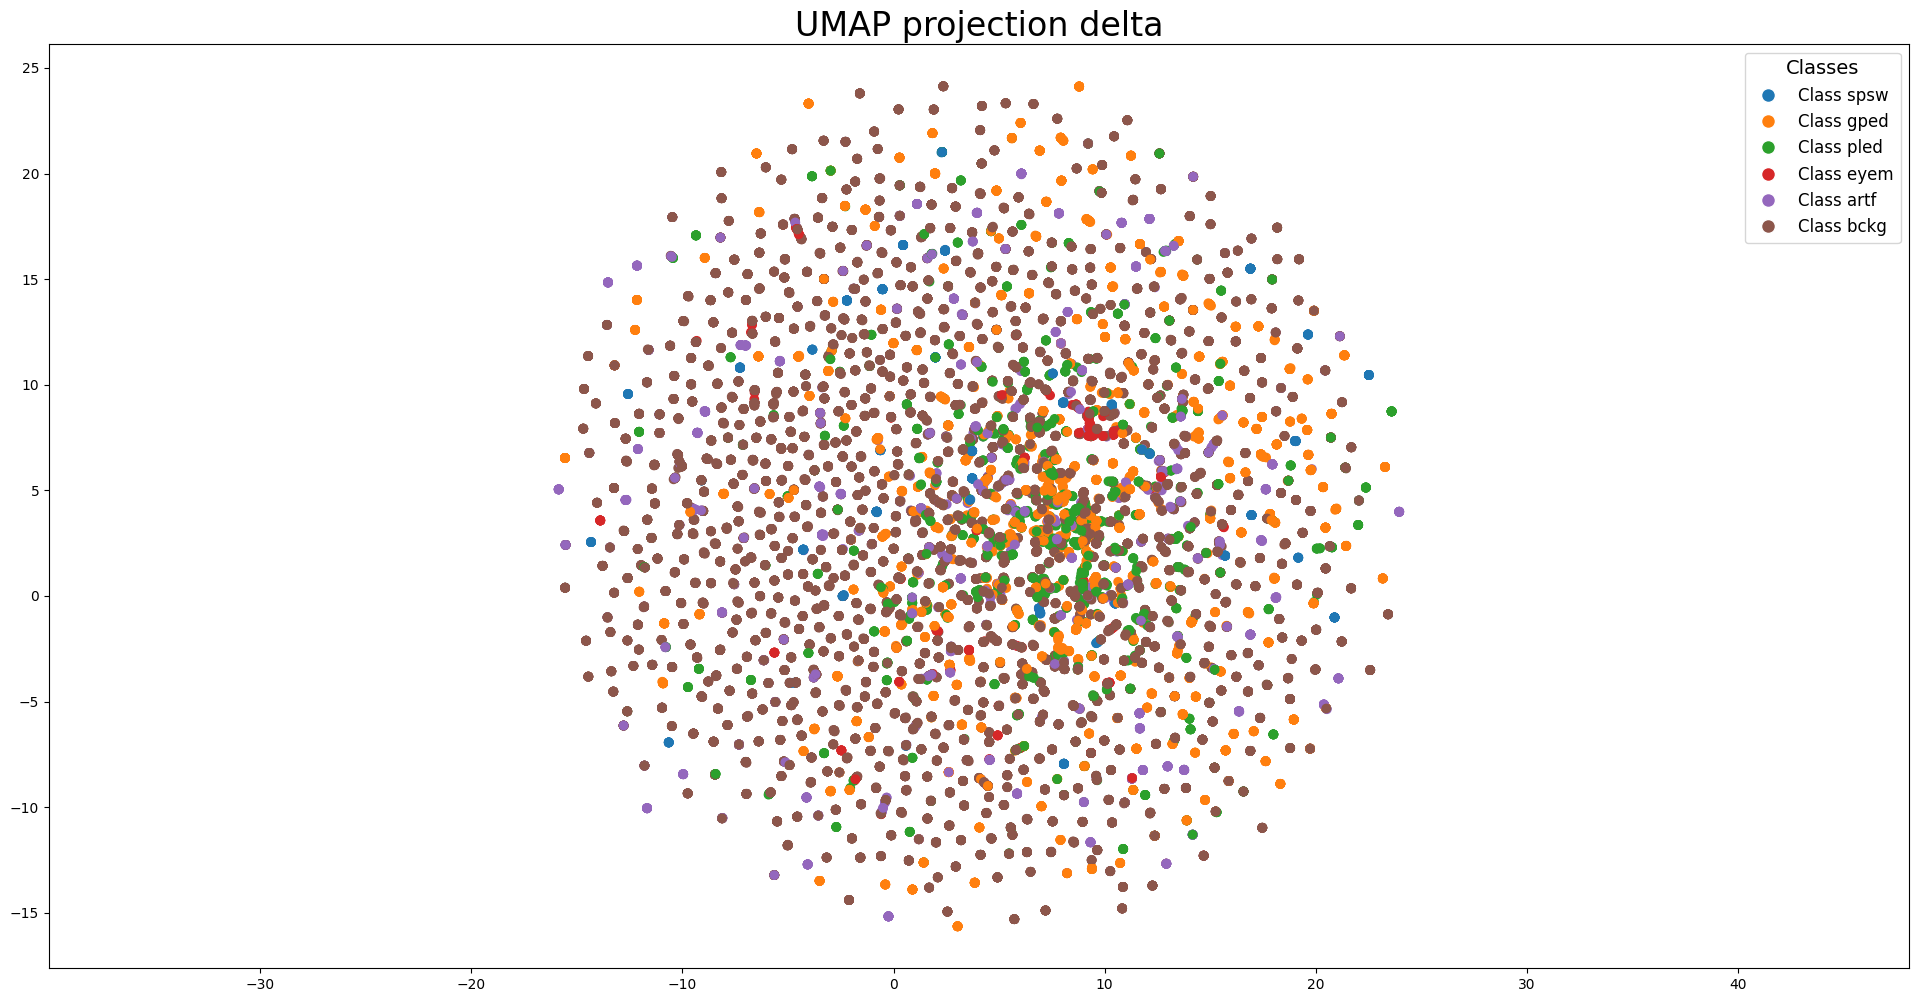

 17%|█▋        | 1/6 [00:20<01:41, 20.26s/it]

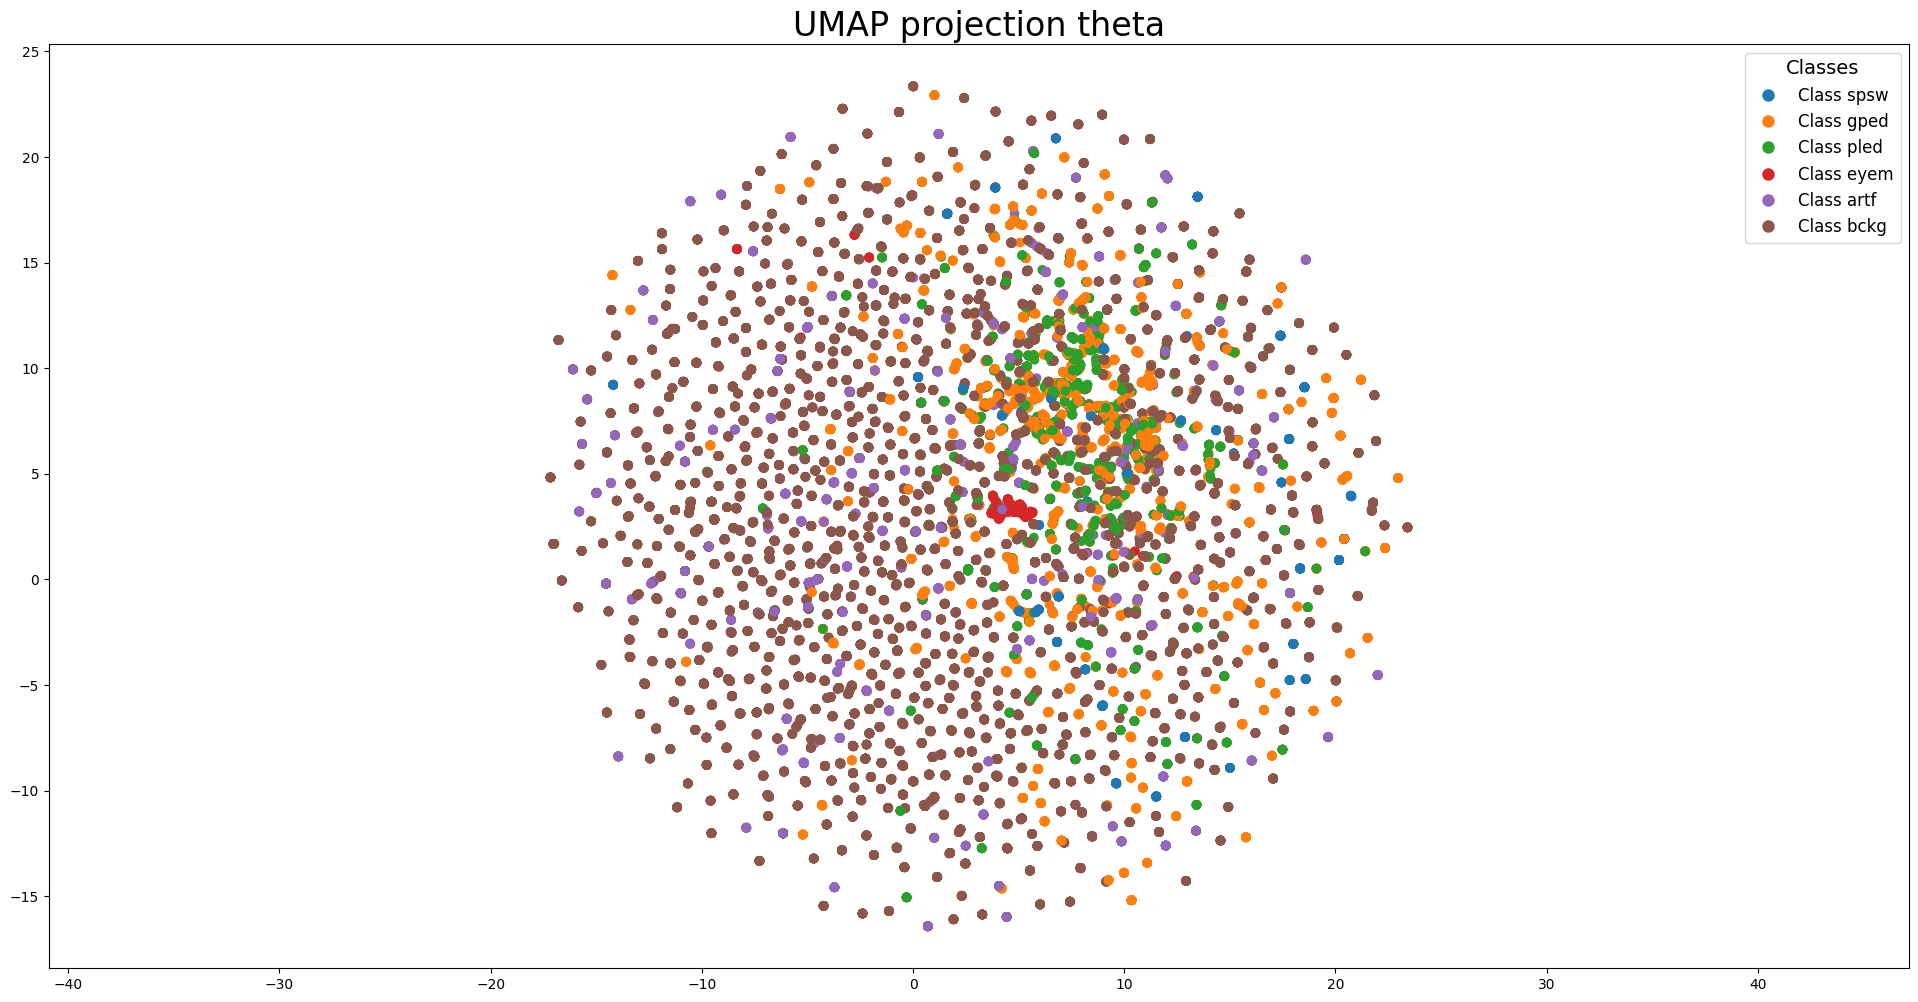

 33%|███▎      | 2/6 [00:26<00:49, 12.28s/it]

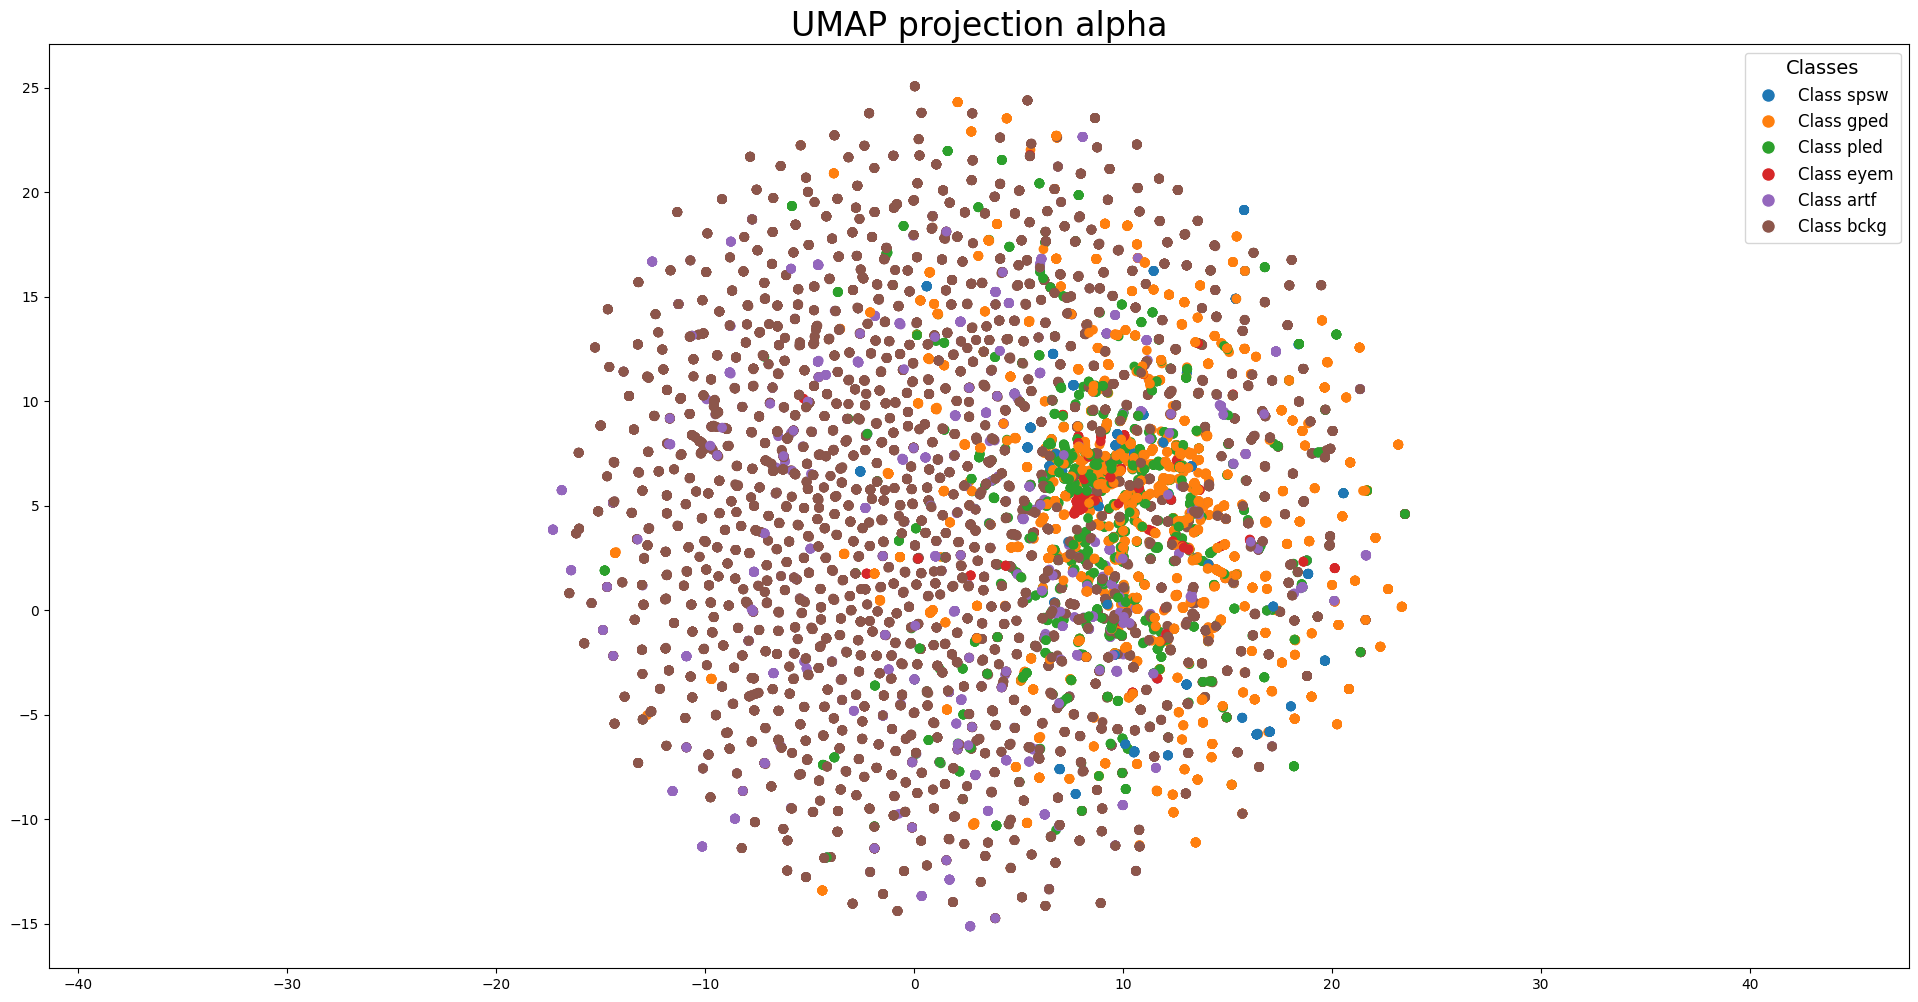

 50%|█████     | 3/6 [00:33<00:29,  9.77s/it]

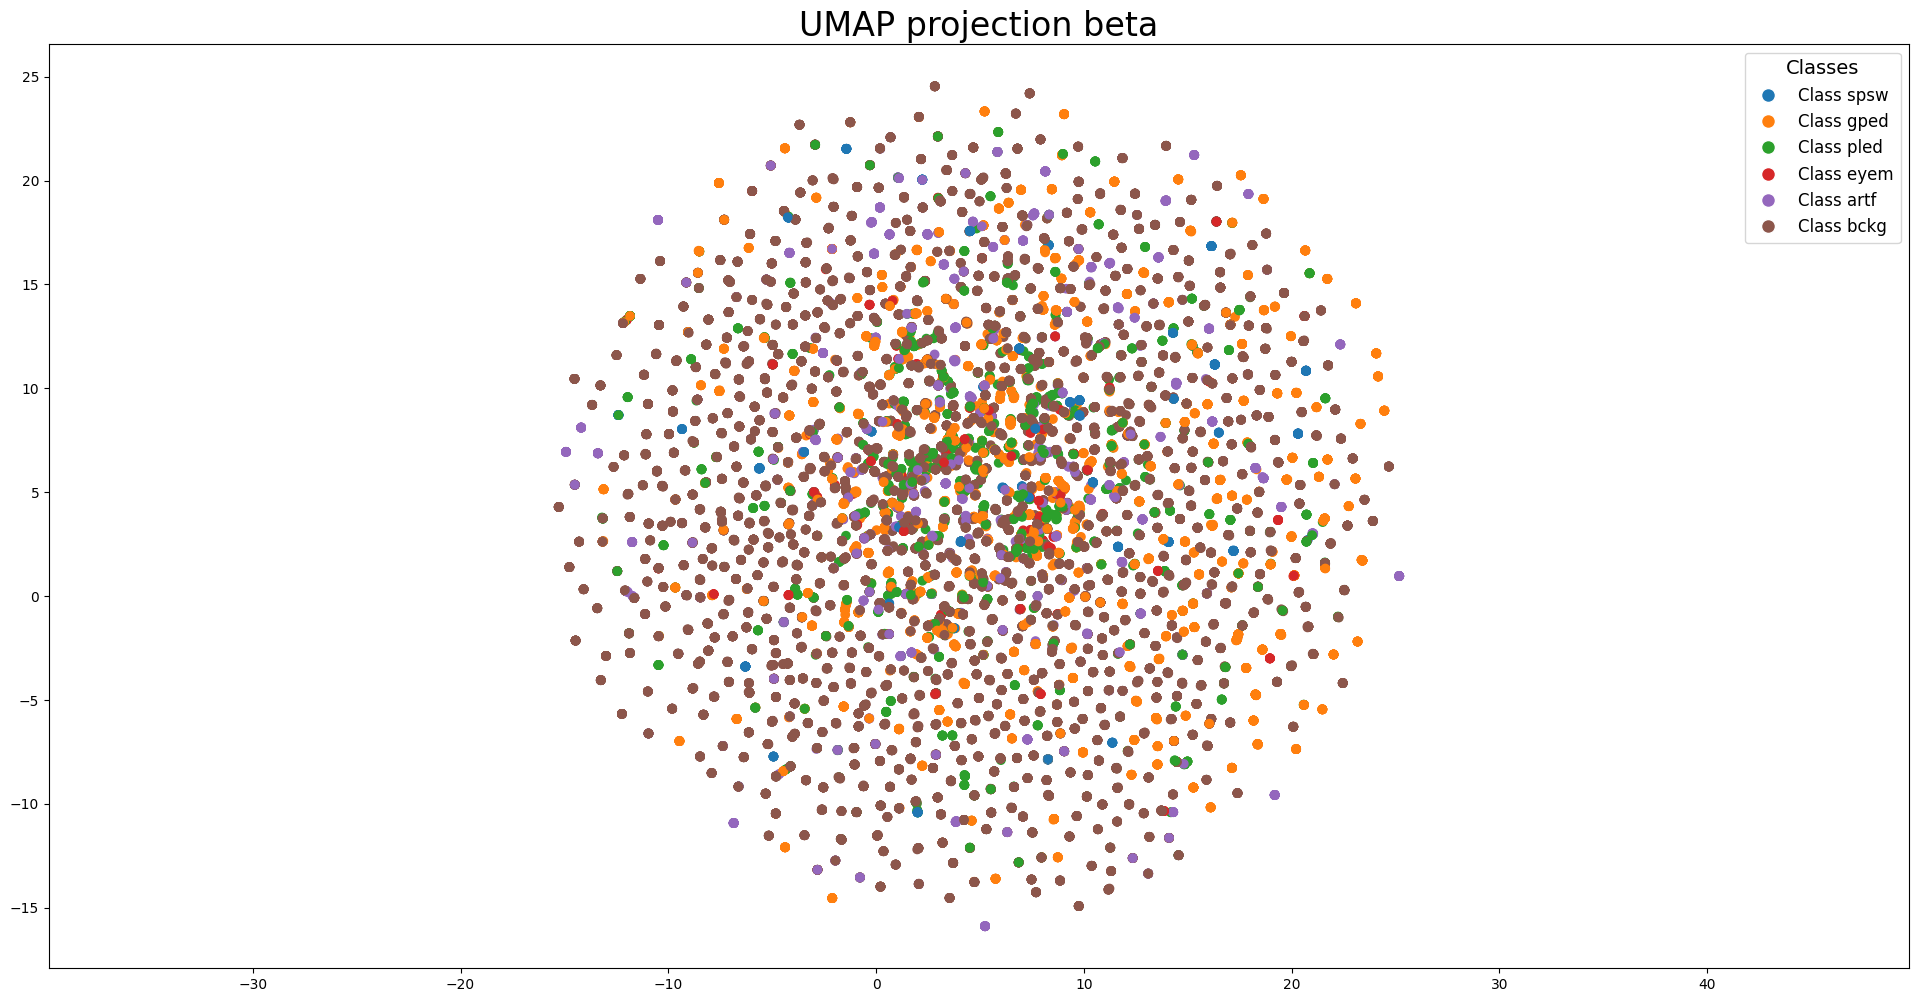

 67%|██████▋   | 4/6 [00:41<00:17,  8.93s/it]

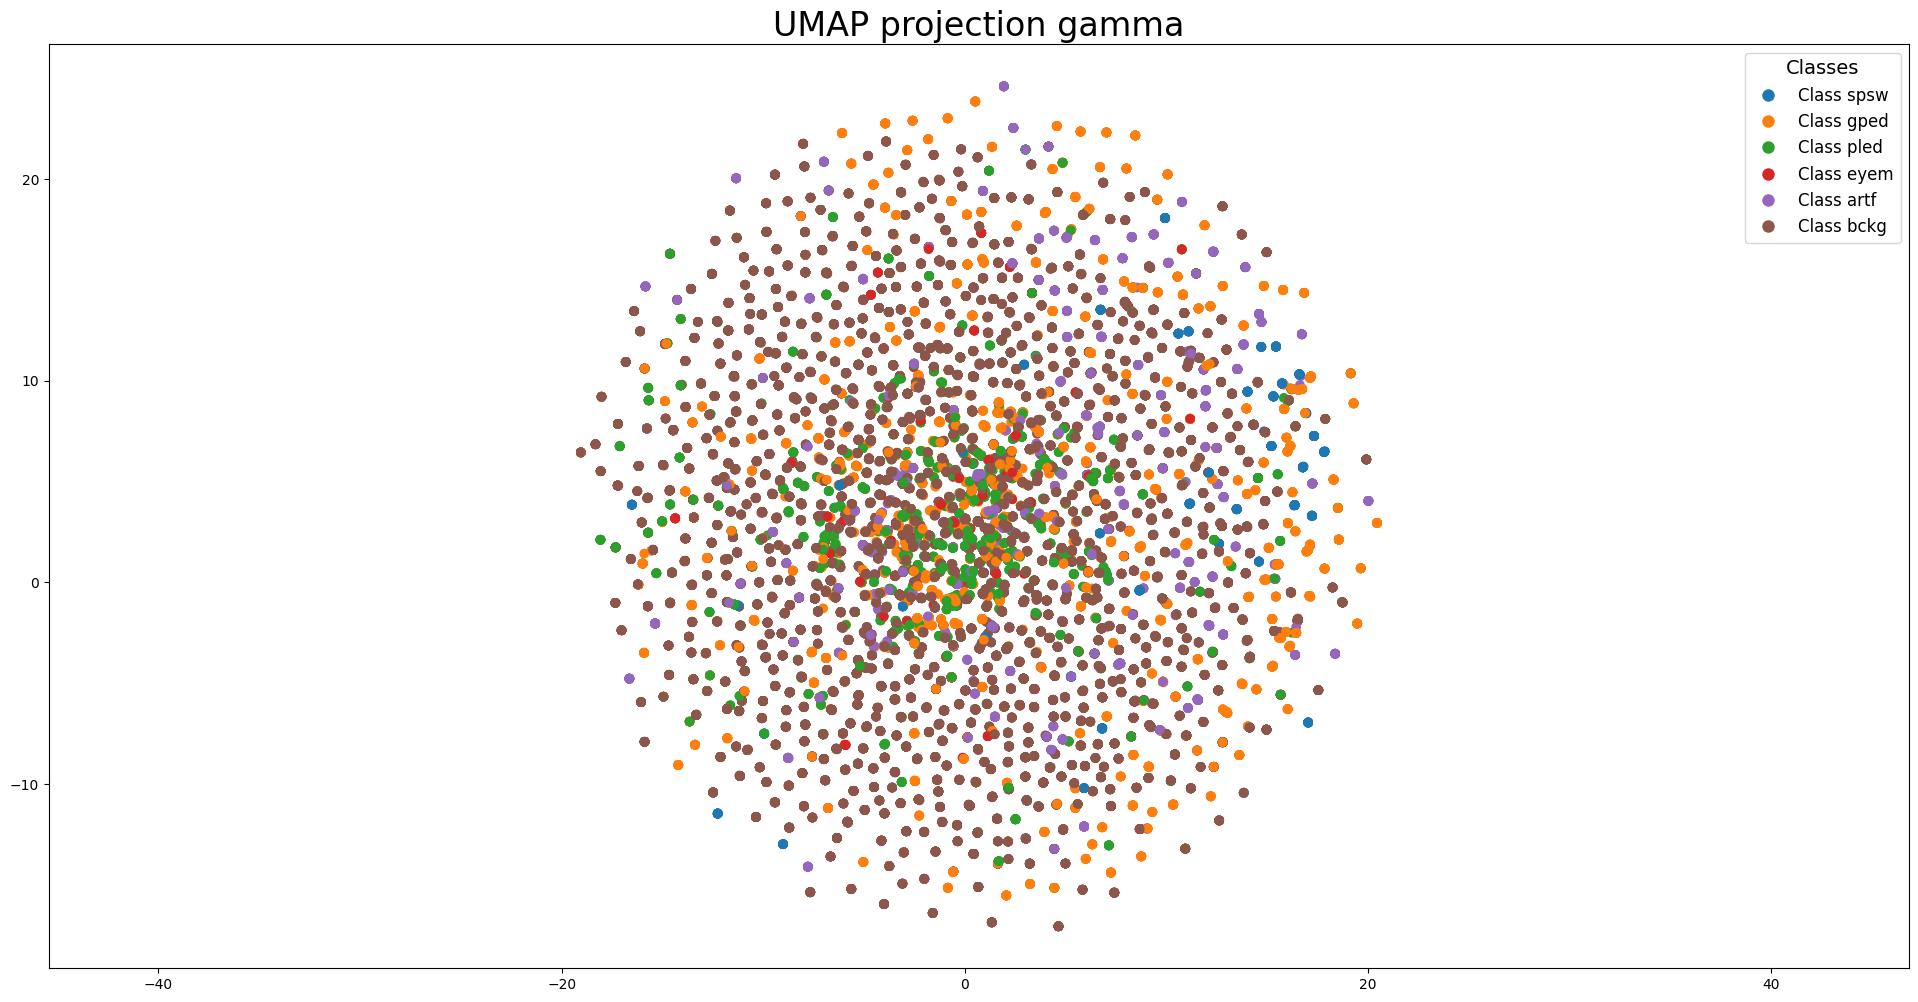

 83%|████████▎ | 5/6 [00:47<00:08,  8.09s/it]

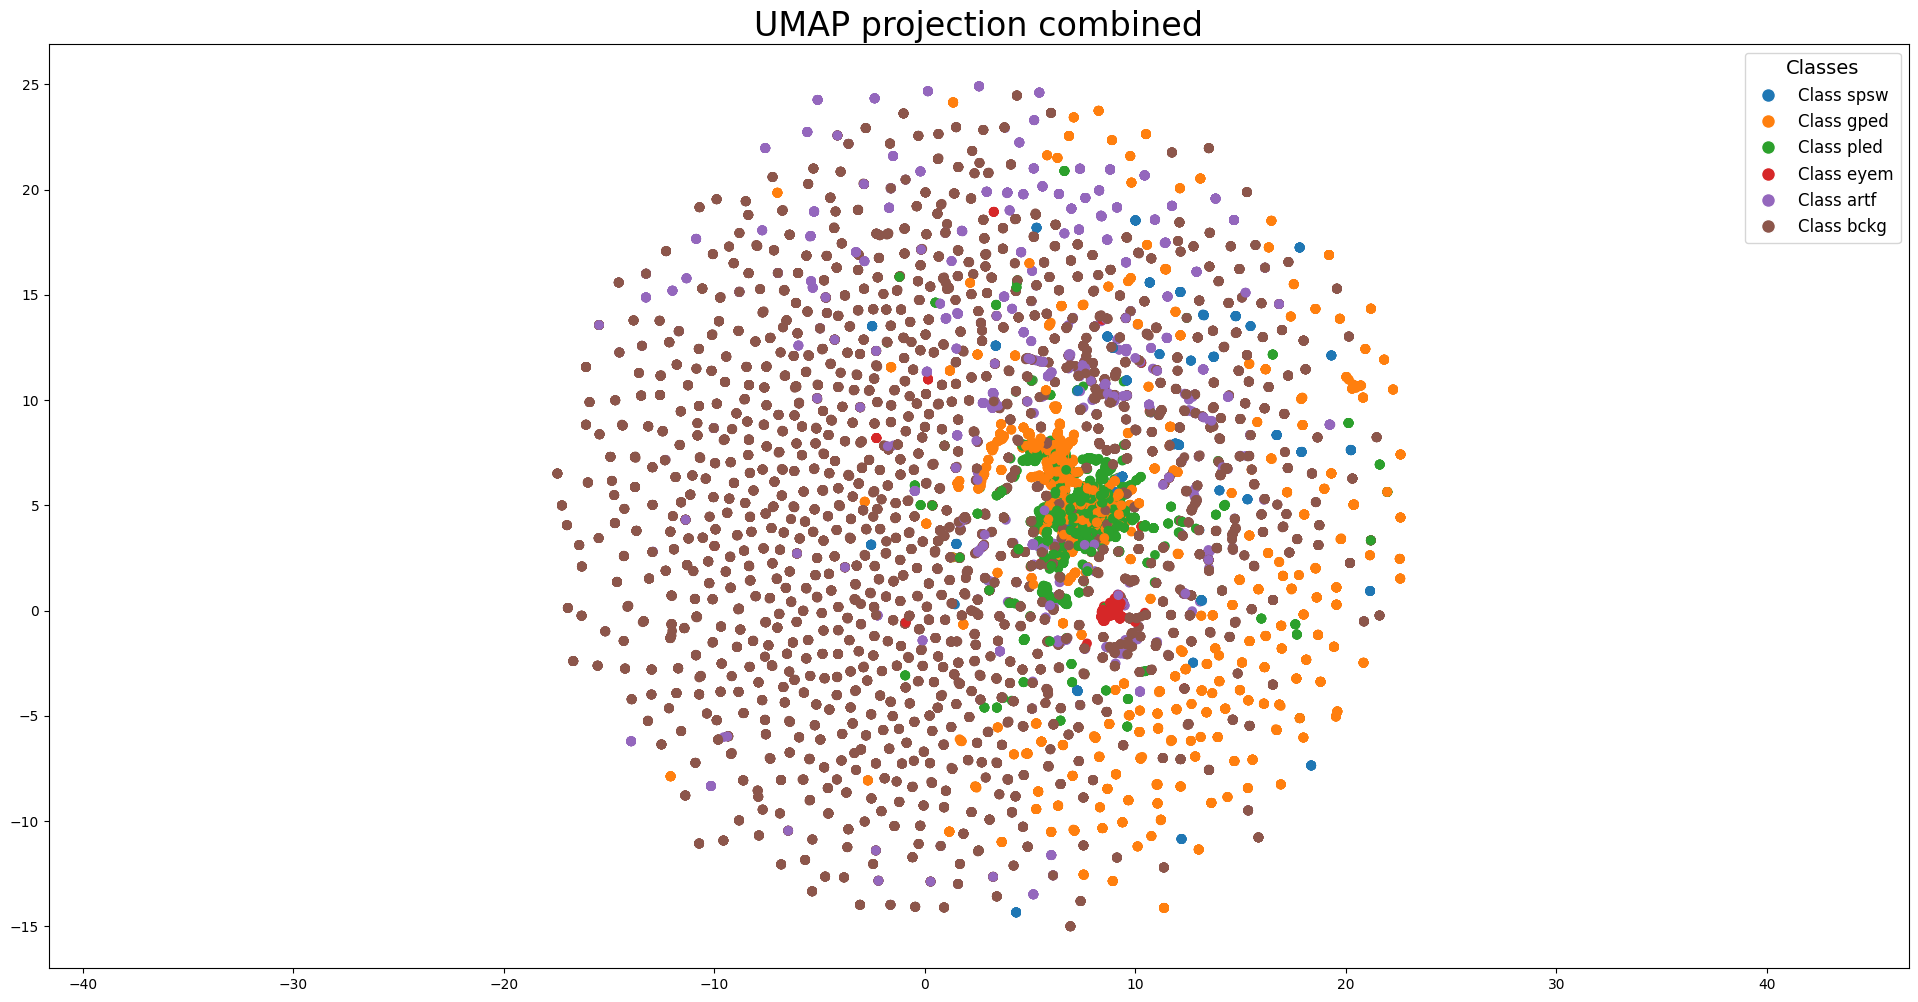

100%|██████████| 6/6 [00:55<00:00,  9.31s/it]


In [25]:
for band in tqdm.tqdm(['delta', 'theta', 'alpha', 'beta', 'gamma', 'combined']):
    if band == 'combined':
        embeddings = reducer2.fit_transform(combined_output_eval_all, job=-1)
    else:
        data = encoding_output_eval_all[band].reshape(encoding_output_eval_all[band].shape[0], -1)
        embeddings = reducer2.fit_transform(data, jobs=-1)
    
    fig = plt.figure(figsize=(24, 12))
    ax = fig.add_subplot()
    scatter = ax.scatter(
        embeddings[:, 0],
        embeddings[:, 1],
        c=[sns.color_palette()[x] for x in output_labels_eval_all]
    )
    
    # Create legend handles
    unique_labels = np.unique(output_labels_eval_all)
    legend_handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=sns.color_palette()[label], markersize=10, label=f'Class {label_to_class[label]}')
        for label in unique_labels
    ]
    ax.legend(handles=legend_handles, title="Classes", fontsize=12, title_fontsize=14)
    
    plt.gca().set_aspect('equal', 'datalim')
    plt.title(f'UMAP projection {band}', fontsize=24)
    plt.show()


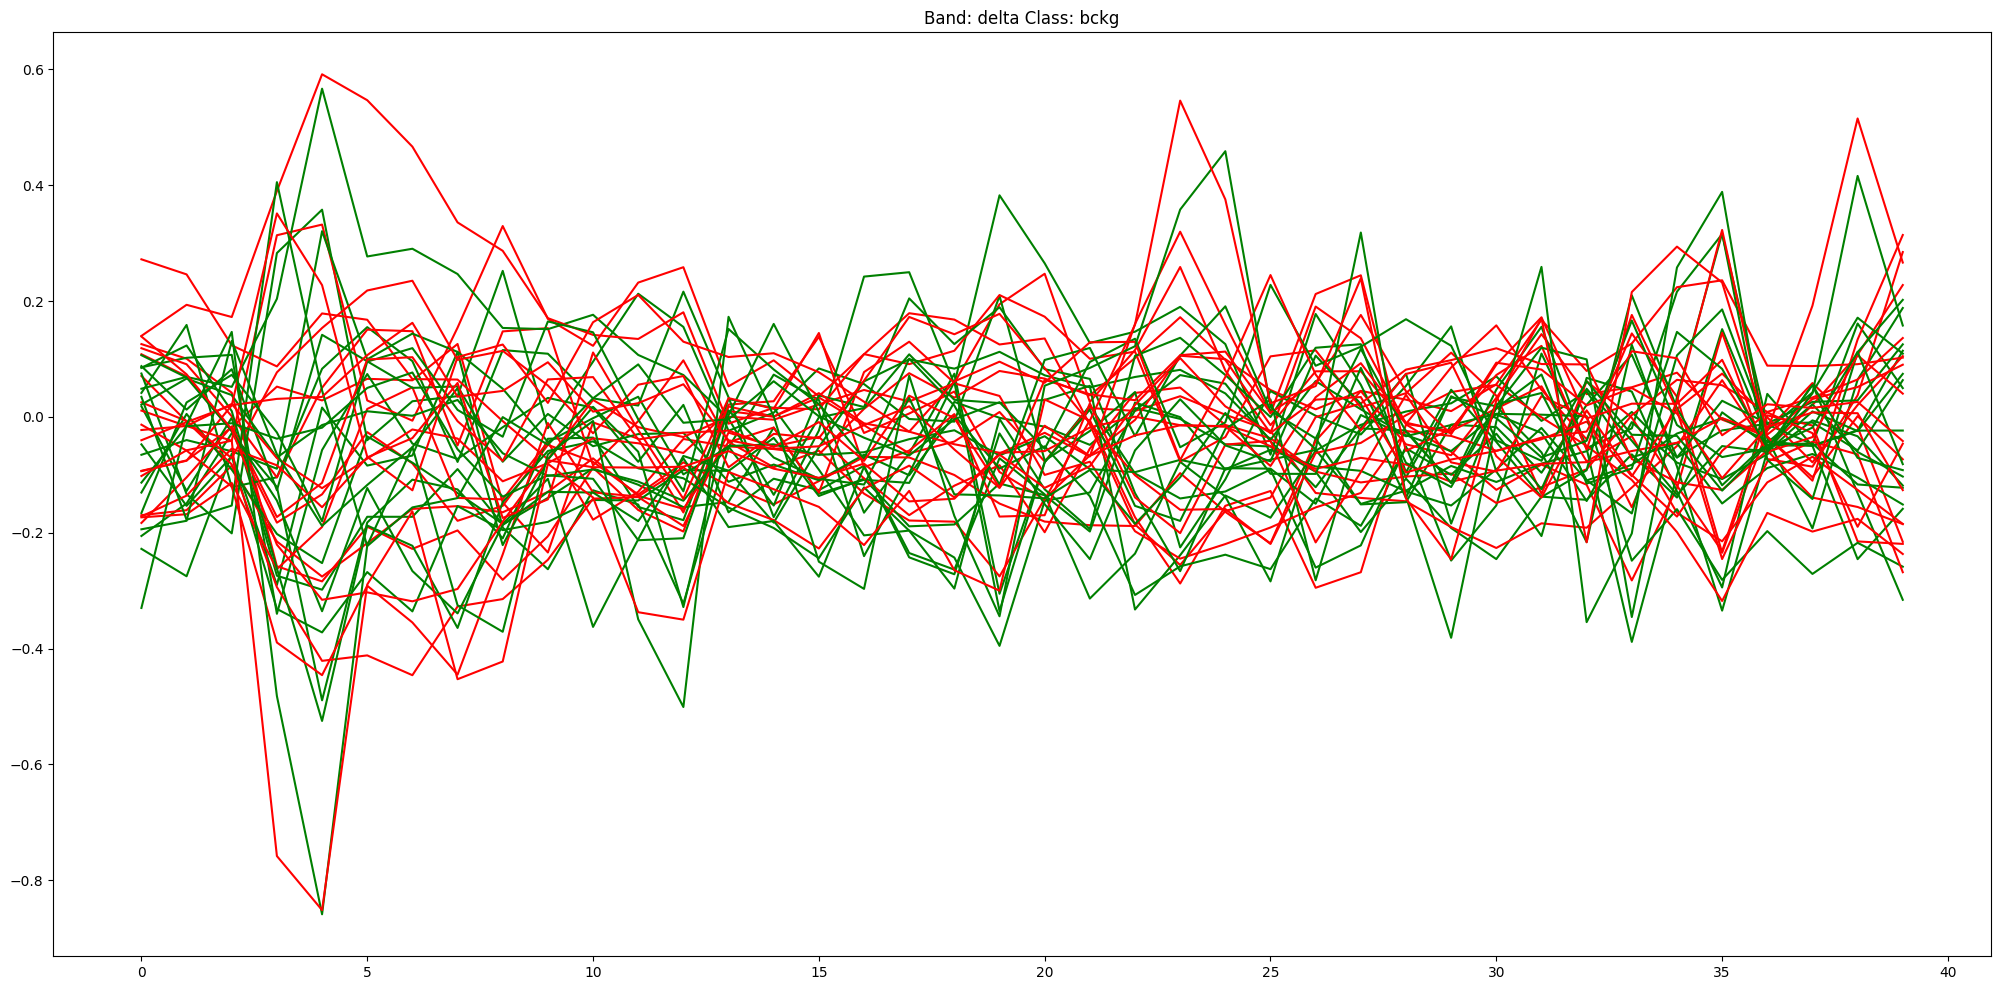

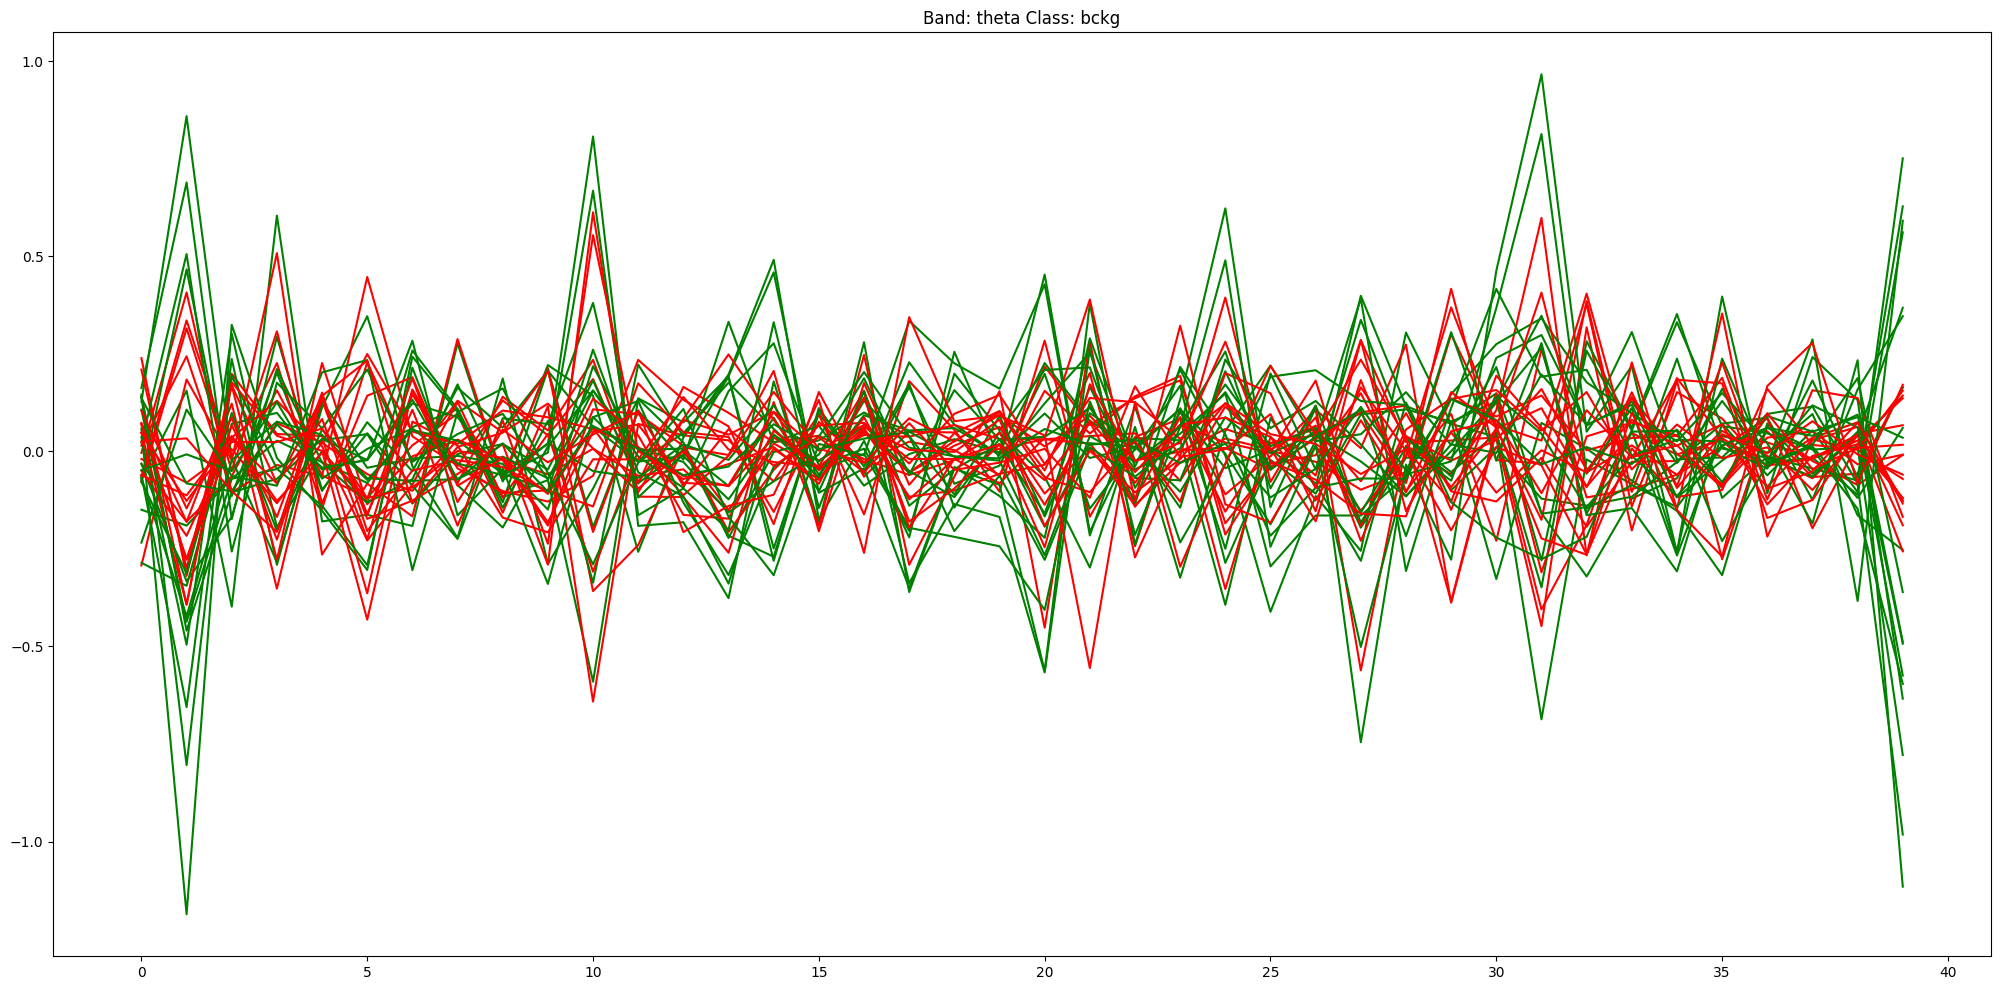

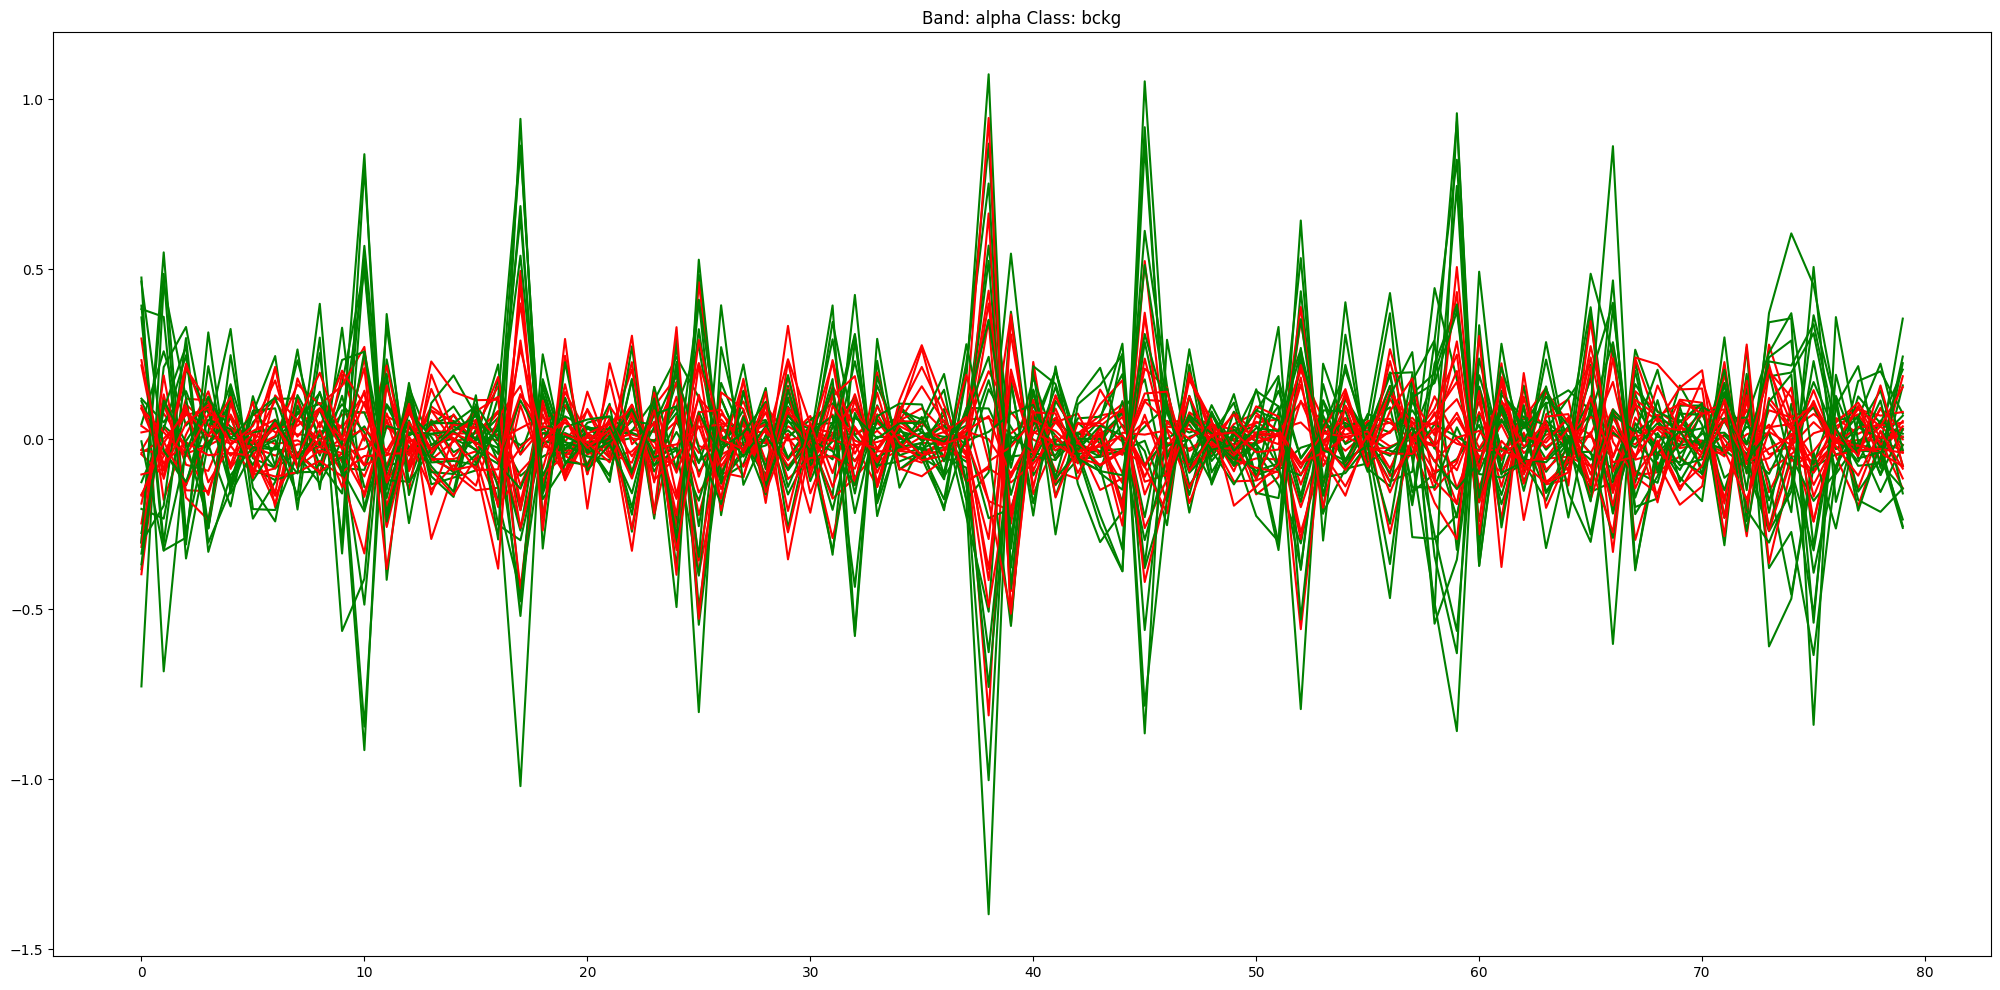

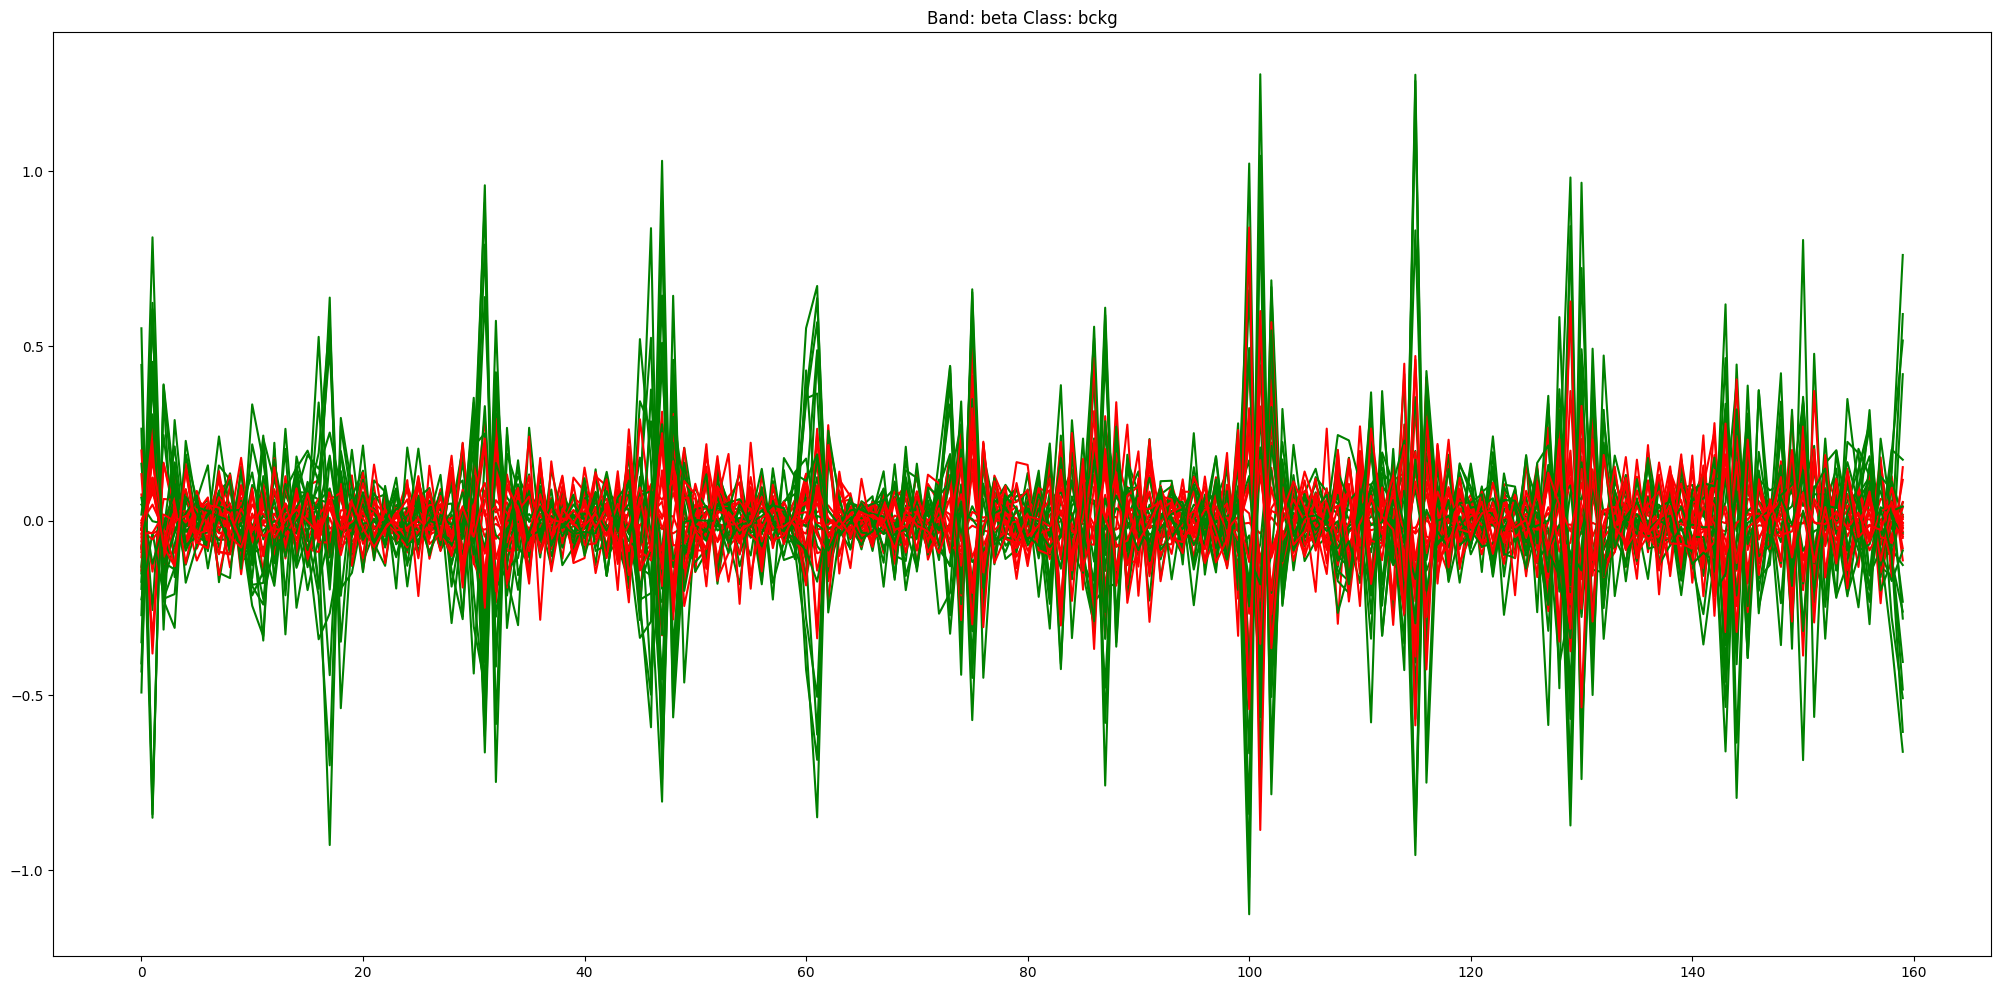

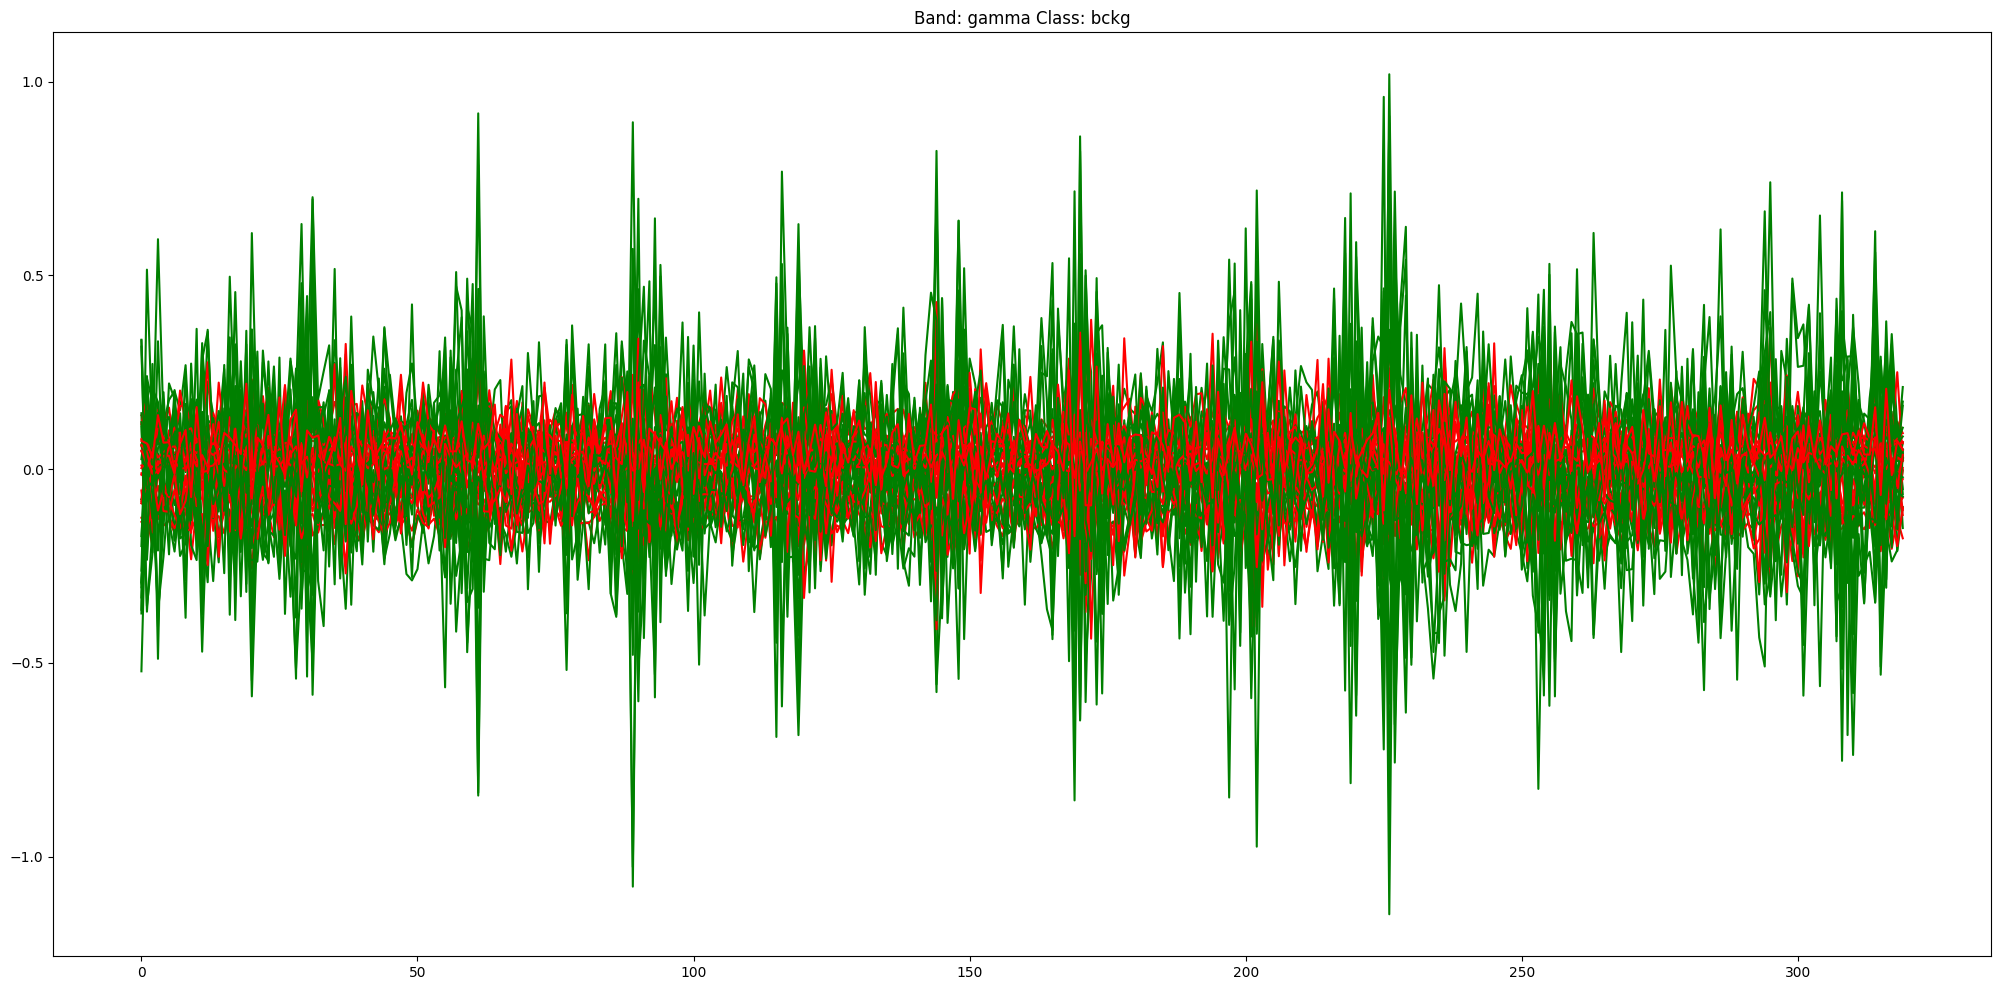

In [26]:
channel = 5
data_idx = 0
for band in ['delta', 'theta', 'alpha', 'beta', 'gamma']:
    plt.figure(figsize=(25, 12))
    for channel in range(19):
        plt.plot(patchified_inputs[band][data_idx, 1, channel, :].cpu().detach().numpy(), label=f"Input {band} Channel {channel}", c="g")
        decoding_plot = decodings[band].reshape(patchified_inputs[band].shape[0], patchified_inputs[band].shape[1], patchified_inputs[band].shape[2], patchified_inputs[band].shape[3])
        plt.plot(decoding_plot[data_idx, 1, channel, :].cpu().detach().numpy(), label=f"Output {band} Channel {channel}", c="r")
    plt.title(f"Band: {band} Class: {label_to_class[output_labels_eval_all[data_idx].item()]}")
    plt.show()

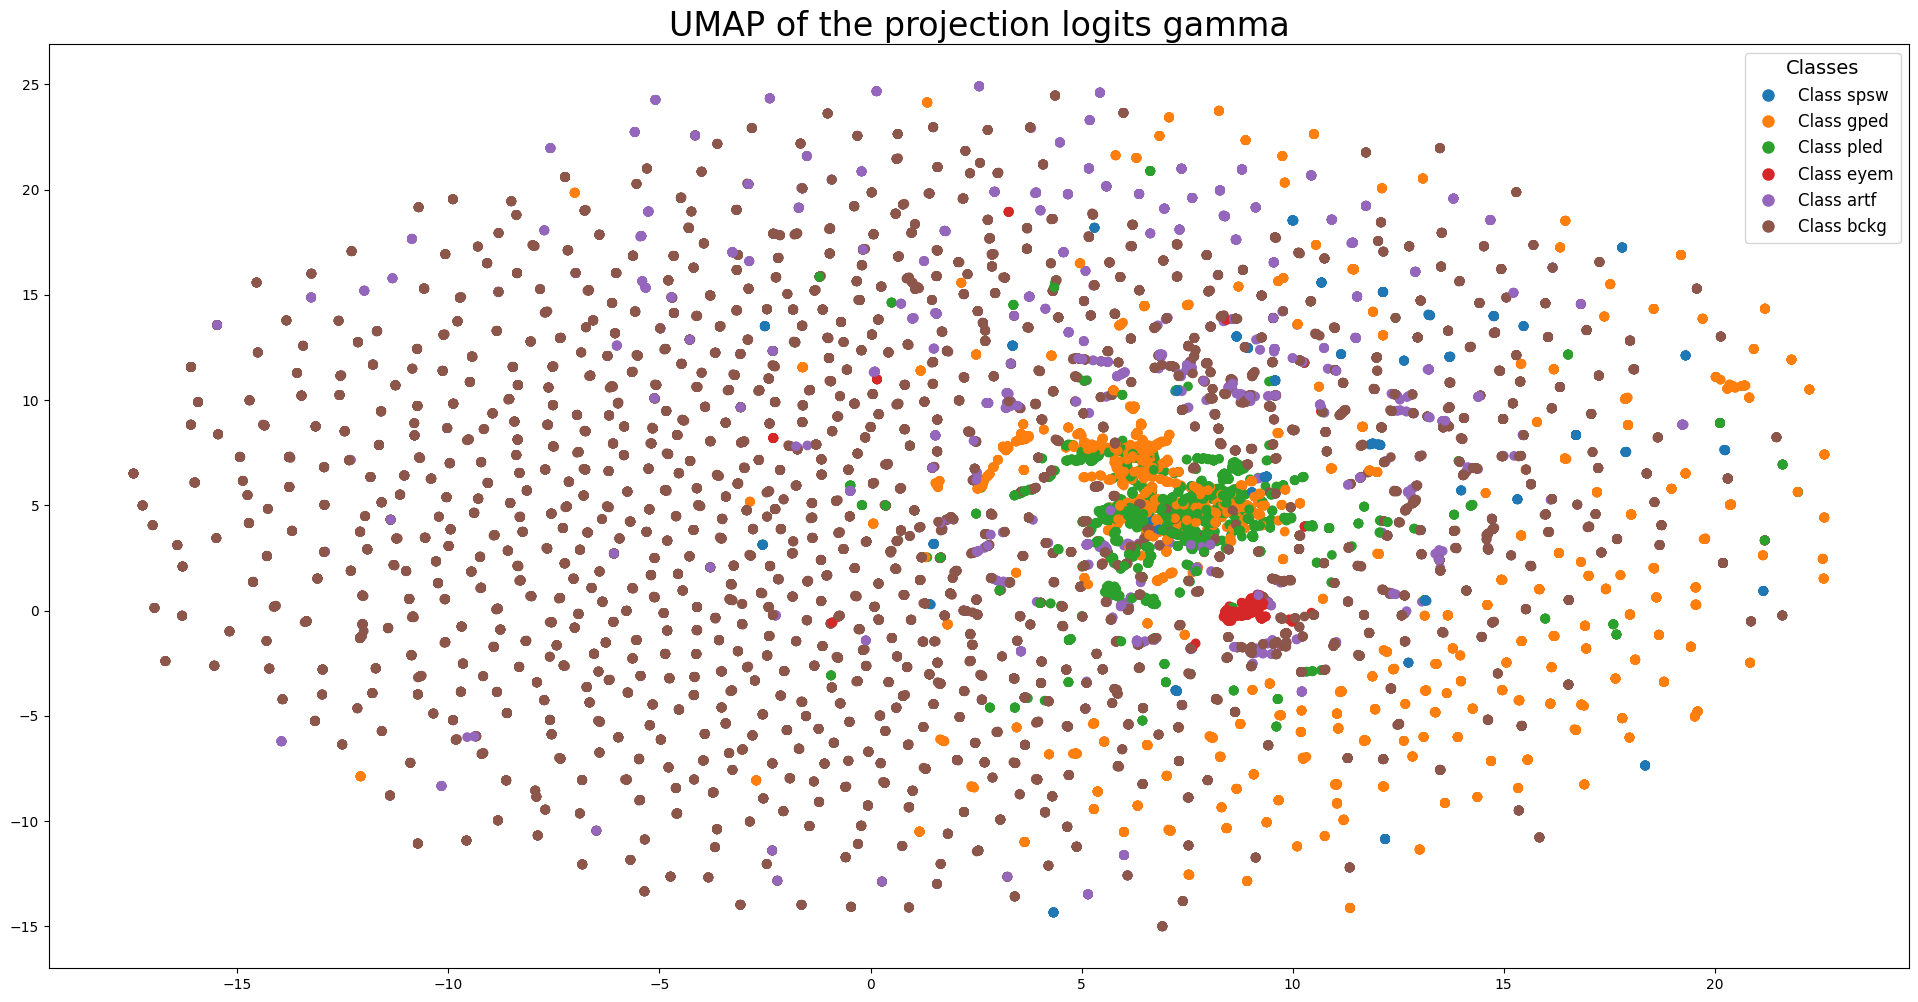

In [28]:
# Define the x-coordinate of the vertical line

fig = plt.figure(figsize=(24, 12))
predictions = reducer2.fit_transform(predictions, job=-1)

# Filter for points of blue color
blue_points = embeddings[output_labels_eval_all == 0]


purple_points = embeddings[output_labels_eval_all == 4]
brown_points = embeddings[output_labels_eval_all == 5]

ax = fig.add_subplot()
ax.scatter(
    embeddings[:, 0],
    embeddings[:, 1],
    c=[sns.color_palette()[x] for x in output_labels_eval_all])

'''
ax.scatter(
    blue_points[:, 0],
    blue_points[:, 1],
    c=[sns.color_palette()[0] for x in range(len(blue_points))])

ax.scatter(
    brown_points[:, 0],
    brown_points[:, 1],
    c=[sns.color_palette()[5] for x in range(len(brown_points))])

ax.scatter(
    purple_points[:, 0],
    purple_points[:, 1],
    c=[sns.color_palette()[4] for x in range(len(purple_points))])
'''  
# Create legend handles
unique_labels = np.unique(output_labels_eval_all)
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=sns.color_palette()[label], markersize=10, label=f'Class {label_to_class[label]}')
    for label in unique_labels
]
ax.legend(handles=legend_handles, title="Classes", fontsize=12, title_fontsize=14)
plt.title(f'UMAP of the projection logits {band}', fontsize=24)
plt.show()